<a href="https://colab.research.google.com/github/andressriosg/Mineria-de-datos/blob/main/datosjohn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocesamiento de los datos

El preprocesamiento de los datos consiste en cargar las bases de datos. Como la tabla de la encuesta Likert corresponde a variables de 1 a 5 con escala de 1=desacuerdo y 5=de acuerdo, se procede a convertir cada una de las preguntas de esta encuesta en una variable tipo *string* pára interpretarla como una variable categórica.

De otra parte, la encuesta de opción múltiple corresponde a una base de datos donde para cada pregunta hay solo una respuesta correcta. Se hace el cambio dejando 0=respuesta incorrecta y 1=respuesta correcta para cada pregunta de este cuestionario. Luego se procede a redefinirlas como varibles tipo *string* para que el software no las asuma como valores numéricos.

In [ ]:
import pandas as pd
import os
os.listdir("/content")
os.listdir("/content/sample_data")
ruta = "/content/DATOS DE LOS DOS CUESTIONARIOS.xlsx"
xls = pd.ExcelFile(ruta)
print(xls.sheet_names)

['INTRUMENTO NdC OPCIÓN MÚLTIPLE', 'INTRUMENTO NdC LIKERT']


In [67]:
vof = pd.read_excel(ruta, sheet_name='INTRUMENTO NdC OPCIÓN MÚLTIPLE')
nuevos_nombres = vof.columns.tolist()
for i in range(40):
    nuevos_nombres[5 + i] = f"P{i+1}"
vof.columns = nuevos_nombres
vof.head(4)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,P1,P2,P3,P4,P5,...,P31,P32,P33,P34,P35,P36,P37,P38,P39,P40
0,ARAQUE,GUTIERREZ,ANA,MARIA,PENSAMIENTO CIENTIFICOS II,2,3,3,0,3,...,3,3,2,3,2,2,3,1,3,2
1,AVENDAÑO,GOMEZ,MARISOL,NaN,DIDACTICA DE LAS CIENCIAS I,2,3,3,2,1,...,2,3,2,2,2,2,1,1,3,2
2,BALLESTEROS,ORTEGA,SARAY,DALEISY,DIDACTICA DE LAS CIENCIAS I,1,1,3,2,1,...,3,3,2,2,3,2,3,2,3,3
3,CACERES,AYALA,SARA,DEL PILAR,DIDACTICA DE LAS CIENCIAS I,2,1,3,2,3,...,3,3,3,2,2,3,3,2,1,2


In [68]:
multiple = pd.read_excel(ruta, sheet_name='INTRUMENTO NdC LIKERT')
nuevos_nombres = multiple.columns.tolist()
for i in range(20):
    nuevos_nombres[5 + i] = f"P{i+1}"
multiple.columns = nuevos_nombres
multiple.head(4)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,ASIGNATURA,P1,P2,P3,P4,P5,...,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20
0,ARAQUE,GUTIERREZ,ANA,MARIA,PENSAMIENTO CIENTIFICOS II,5.0,4.0,4.0,5.0,5.0,...,5.0,3.0,5.0,1.0,3.0,4.0,3.0,4.0,4.0,5.0
1,AVENDAÑO,GOMEZ,MARISOL,NaN,DIDACTICA DE LAS CIENCIAS I,5.0,4.0,5.0,5.0,1.0,...,3.0,5.0,5.0,1.0,3.0,5.0,4.0,3.0,5.0,3.0
2,BALLESTEROS,ORTEGA,SARAY,DALEISY,DIDACTICA DE LAS CIENCIAS I,4.0,4.0,3.0,5.0,4.0,...,3.0,5.0,4.0,3.0,5.0,4.0,4.0,5.0,5.0,5.0
3,CACERES,AYALA,SARA,DEL PILAR,DIDACTICA DE LAS CIENCIAS I,5.0,4.0,5.0,5.0,3.0,...,5.0,5.0,5.0,3.0,4.0,4.0,5.0,5.0,5.0,3.0


In [69]:
lista = [2,3,3,2,1,3,1,1,2,3, 1,1,1,3,3,3,2,2,2,1,
         3,1,1,2,2,2,1,3,3,1,3,3,1,3,1,3,1,2,1,2]
len(lista)

40

In [71]:
vof_bin = vof.copy()
col_inicio = 5
columnas_preguntas = vof_bin.columns[col_inicio:col_inicio+len(lista)]
for col, respuesta_correcta in zip(columnas_preguntas, lista):
    vof_bin[col] = (vof_bin[col] == respuesta_correcta).astype(int)
vof_bin.head(4)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,P1,P2,P3,P4,P5,...,P31,P32,P33,P34,P35,P36,P37,P38,P39,P40
0,ARAQUE,GUTIERREZ,ANA,MARIA,PENSAMIENTO CIENTIFICOS II,1,1,1,0,0,...,1,1,0,1,0,0,0,0,0,1
1,AVENDAÑO,GOMEZ,MARISOL,NaN,DIDACTICA DE LAS CIENCIAS I,1,1,1,1,1,...,0,1,0,0,0,0,1,0,0,1
2,BALLESTEROS,ORTEGA,SARAY,DALEISY,DIDACTICA DE LAS CIENCIAS I,0,0,1,1,1,...,1,1,0,0,0,0,0,1,0,0
3,CACERES,AYALA,SARA,DEL PILAR,DIDACTICA DE LAS CIENCIAS I,1,0,1,1,0,...,1,1,0,0,0,1,0,1,1,1


Hay preguntas que no fueron respondidas por alguno de los estudiantes. Las correspondientes datos serán omitidos al momento de calcular las medidas descriptivas.

Como las variables correspondientes a cada una de las preguntas de la encuesta de Linkert son ordinales categóricas (denotan orden de acuerdo) y la variables de la encuesta de selección múltiple son dicotómicas y cualitativas se procede a calcular las siguientes medidas de asociación:
* Coeficiente de correlación por Rangos de Kendall
* Coeficiente de correlación de Spearman
* Coeficiente biserial de Rangos de Mann-Whitney

In [99]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np

cols_vof = columnas_preguntas
cols_likert = [f"P{i}" for i in range(1, 21)]

# matrices vacías
matriz_rho = pd.DataFrame(index=cols_vof, columns=cols_likert, dtype=float)
matriz_p   = pd.DataFrame(index=cols_vof, columns=cols_likert, dtype=float)

for vof_item in cols_vof:
    for likert_item in cols_likert:

        df_temp = pd.concat(
            [vof_bin[vof_item], multiple[likert_item]],
            axis=1
        ).dropna()

        if df_temp.iloc[:,0].nunique() > 1 and df_temp.iloc[:,1].nunique() > 1:

            rho, p = spearmanr(df_temp.iloc[:,0], df_temp.iloc[:,1])

            matriz_rho.loc[vof_item, likert_item] = rho
            matriz_p.loc[vof_item, likert_item]   = p

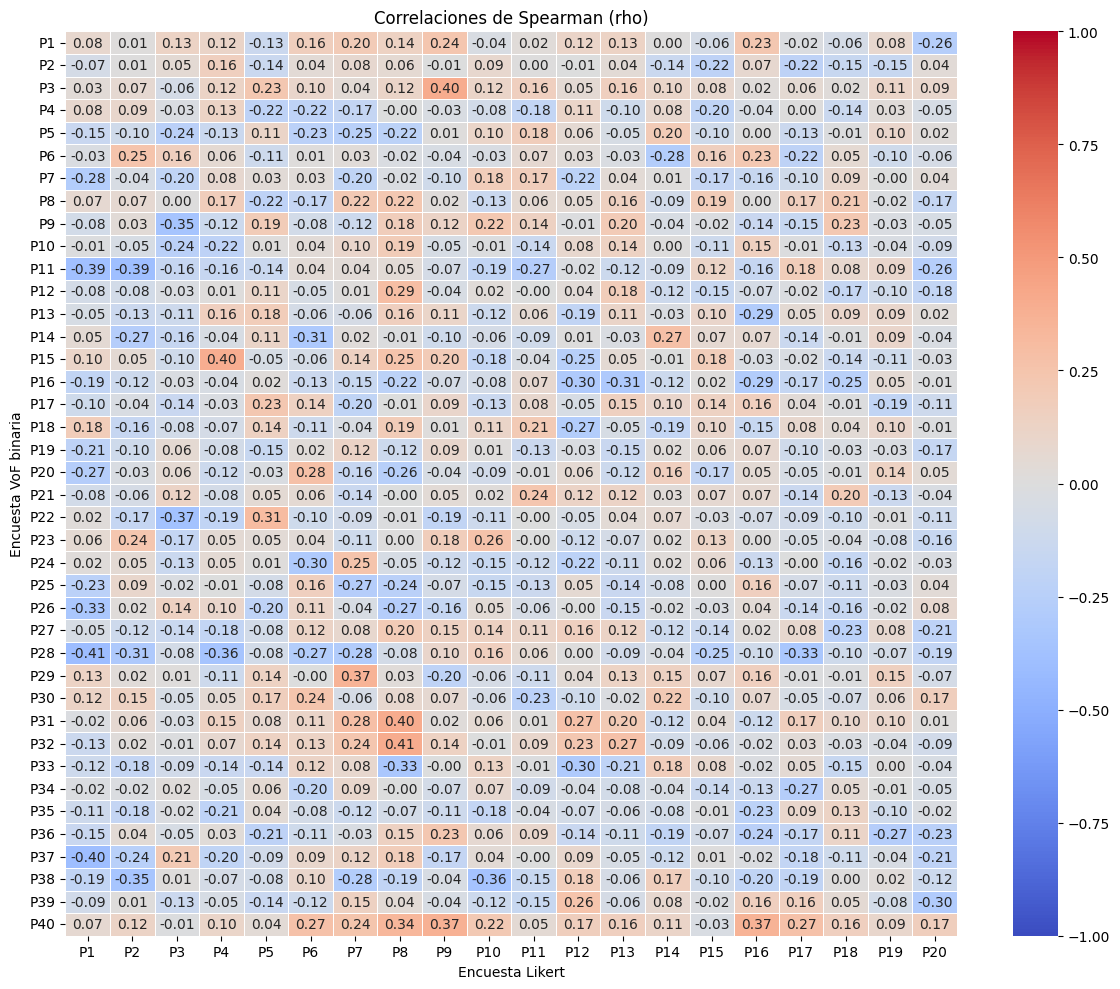

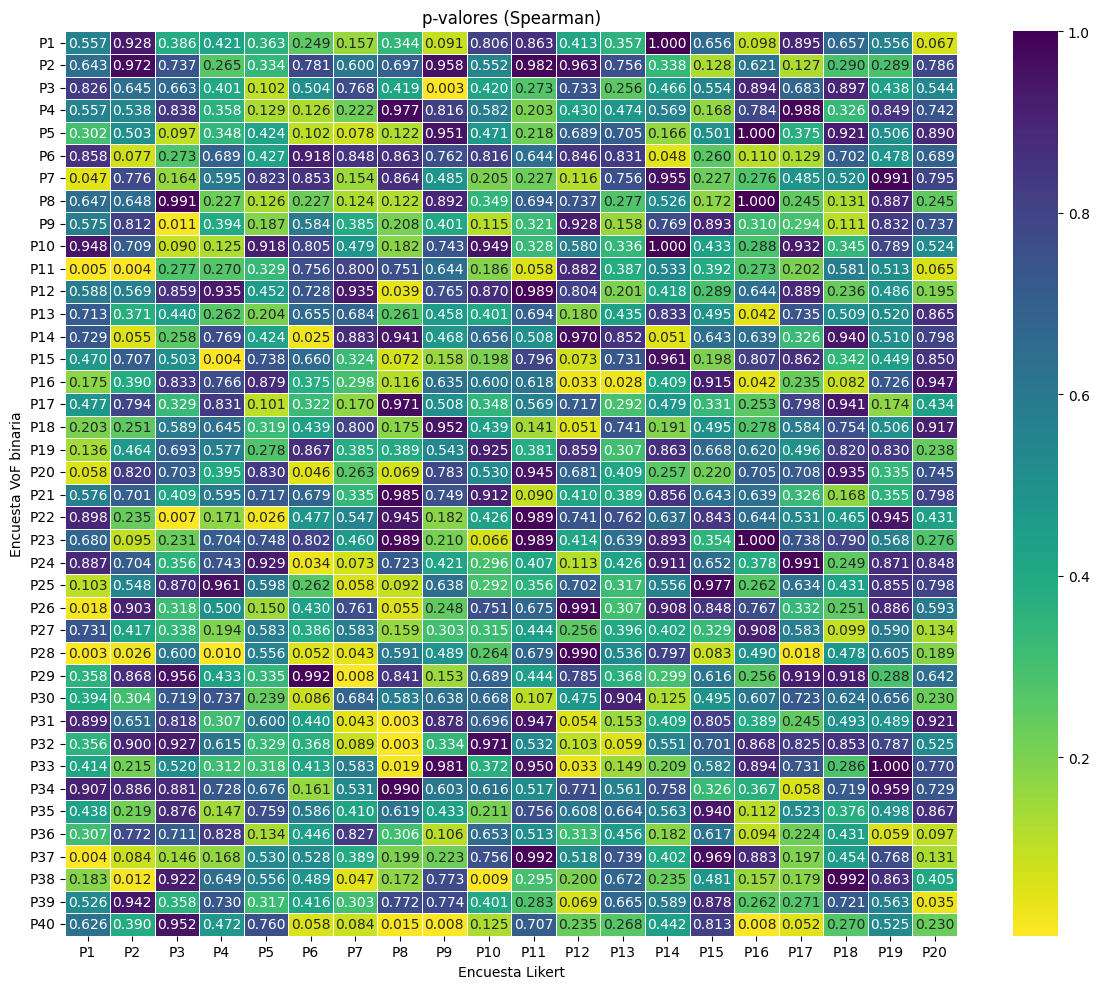

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

# ===== HEATMAP RHO =====
plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_rho,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title("Correlaciones de Spearman (rho)")
plt.xlabel("Encuesta Likert")
plt.ylabel("Encuesta VoF binaria")
plt.tight_layout()
plt.show()


# ===== HEATMAP P-VALORES =====
plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_p,
    annot=True,
    fmt=".3f",
    cmap="viridis_r",
    linewidths=0.5
)
plt.title("p-valores (Spearman)")
plt.xlabel("Encuesta Likert")
plt.ylabel("Encuesta VoF binaria")
plt.tight_layout()
plt.show()

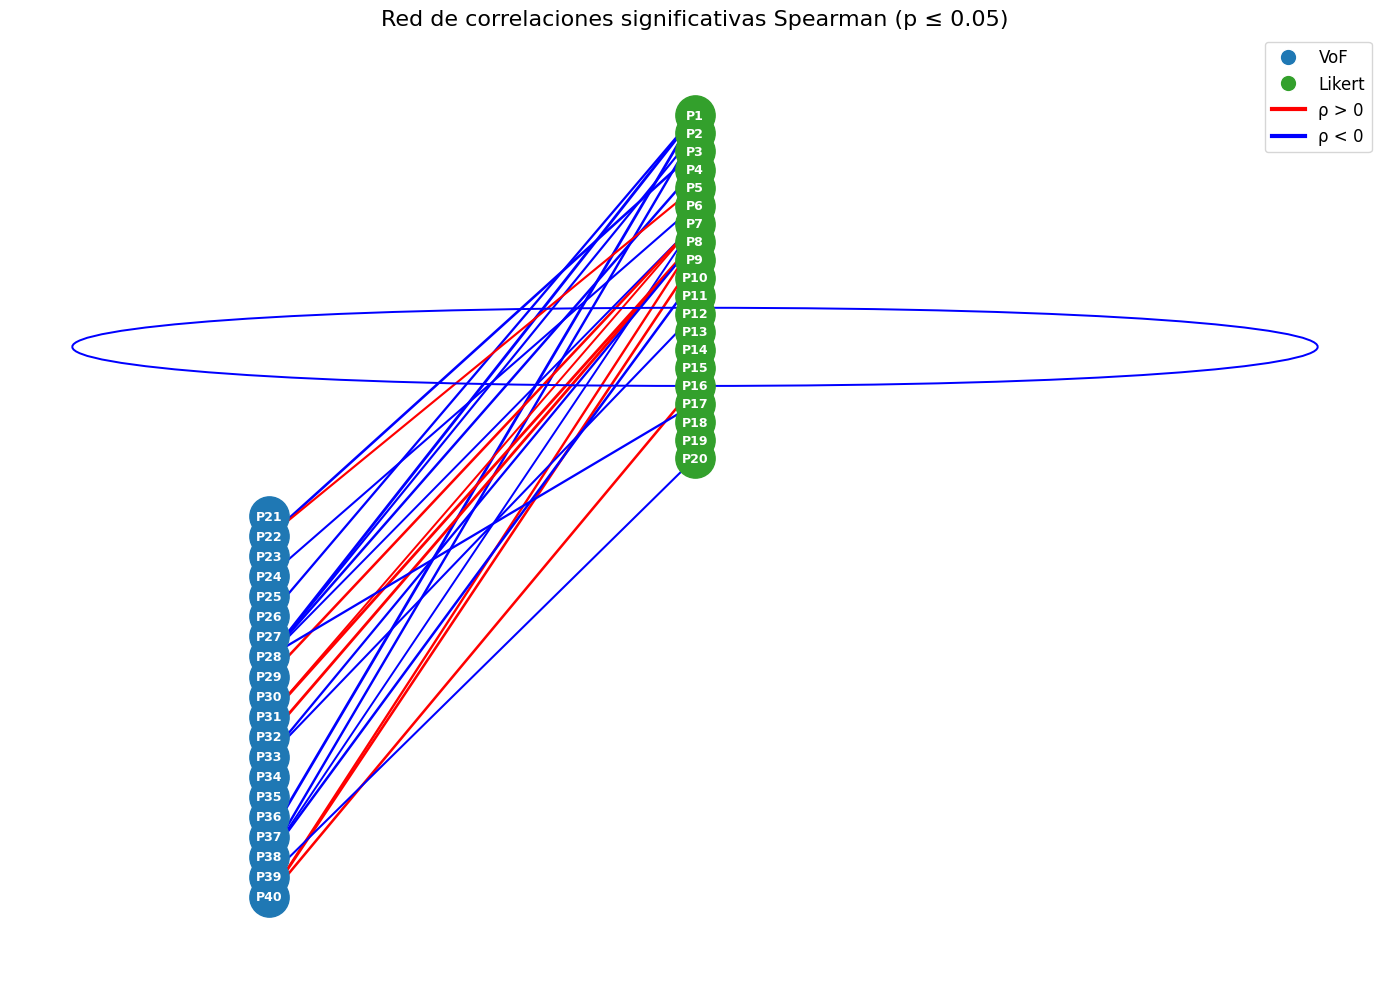

In [112]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

# Nivel de significancia
alpha = 0.05

# Crear grafo
G = nx.Graph()

# Nodos VoF
for vof_item in columnas_preguntas:
    G.add_node(vof_item, tipo='VoF')

# Nodos Likert
likert_items = [f"P{i}" for i in range(1, 21)]
for likert_item in likert_items:
    G.add_node(likert_item, tipo='Likert')

# Agregar aristas solo significativas (p <= alpha)
for vof_item in columnas_preguntas:
    for likert_item in likert_items:
        p_val = matriz_p.loc[vof_item, likert_item]
        coef  = matriz_rho.loc[vof_item, likert_item]
        if pd.notna(coef) and pd.notna(p_val) and p_val <= alpha:
            G.add_edge(vof_item, likert_item, weight=coef)

# Layout tipo bipartito horizontal
pos = {}
for i, vof_item in enumerate(columnas_preguntas):
    pos[vof_item] = (0, -i)
for i, likert_item in enumerate(likert_items):
    pos[likert_item] = (1, -i*0.9)

# Dibujar nodos con colores y tamaño
vof_nodes = [n for n,d in G.nodes(data=True) if d['tipo']=='VoF']
likert_nodes = [n for n,d in G.nodes(data=True) if d['tipo']=='Likert']

plt.figure(figsize=(14,10))
nx.draw_networkx_nodes(G, pos, nodelist=vof_nodes, node_color="#1f78b4", node_size=800, label="VoF")
nx.draw_networkx_nodes(G, pos, nodelist=likert_nodes, node_color="#33a02c", node_size=800, label="Likert")

# Dibujar aristas con color según signo y grosor según magnitud
edges = G.edges(data=True)
edge_colors = ['red' if d['weight']>0 else 'blue' for (u,v,d) in edges]
edge_widths = [abs(d['weight'])*5 for (u,v,d) in edges]
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths)

# Etiquetas en blanco para contraste
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', font_color='white')

# Leyenda manual
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='VoF', markerfacecolor='#1f78b4', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Likert', markerfacecolor='#33a02c', markersize=12),
    Line2D([0], [0], color='red', lw=3, label='ρ > 0'),
    Line2D([0], [0], color='blue', lw=3, label='ρ < 0'),
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.title(f"Red de correlaciones significativas Spearman (p ≤ {alpha})", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

Las preguntas 14, 15 y 19 no están correlacionadas con ninguna de las preguntas de la encuesta de Likert, con una confianza del 95% de acuerdo con la prueba de Hipótesis con base en el coeficiente de Spearman.

In [105]:
from scipy.stats import kendalltau
import pandas as pd
import numpy as np

cols_vof = columnas_preguntas
cols_likert = [f"P{i}" for i in range(1, 21)]

# matrices vacías para coeficiente tau y p-valor
matriz_tau = pd.DataFrame(index=cols_vof, columns=cols_likert, dtype=float)
matriz_p_kendall = pd.DataFrame(index=cols_vof, columns=cols_likert, dtype=float)

for vof_item in cols_vof:
    for likert_item in cols_likert:

        # tomar solo filas sin NA
        df_temp = pd.concat(
            [vof_bin[vof_item], multiple[likert_item]],
            axis=1
        ).dropna()

        # calcular Kendall solo si hay más de 1 valor en ambas variables
        if df_temp.iloc[:,0].nunique() > 1 and df_temp.iloc[:,1].nunique() > 1:
            tau, p = kendalltau(df_temp.iloc[:,0], df_temp.iloc[:,1])
            matriz_tau.loc[vof_item, likert_item] = tau
            matriz_p_kendall.loc[vof_item, likert_item] = p

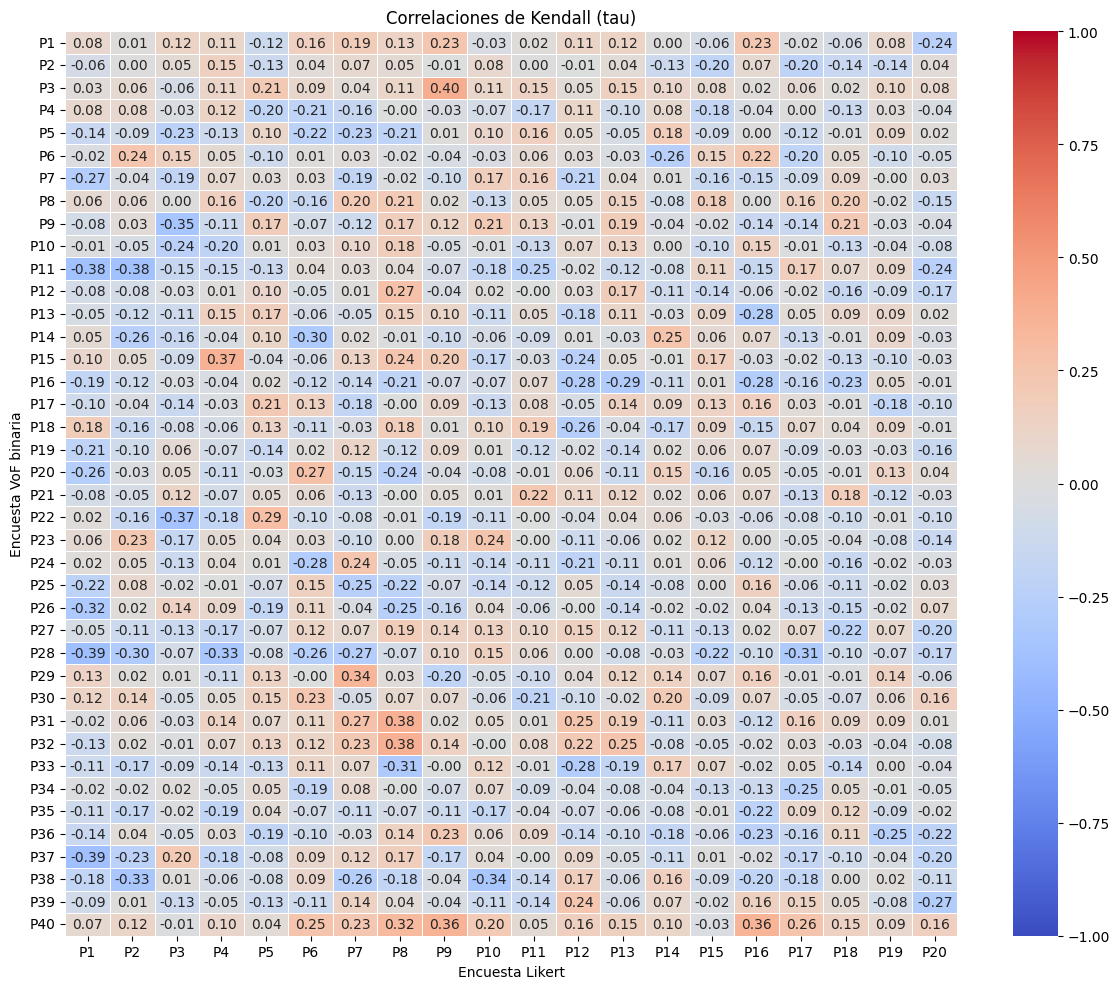

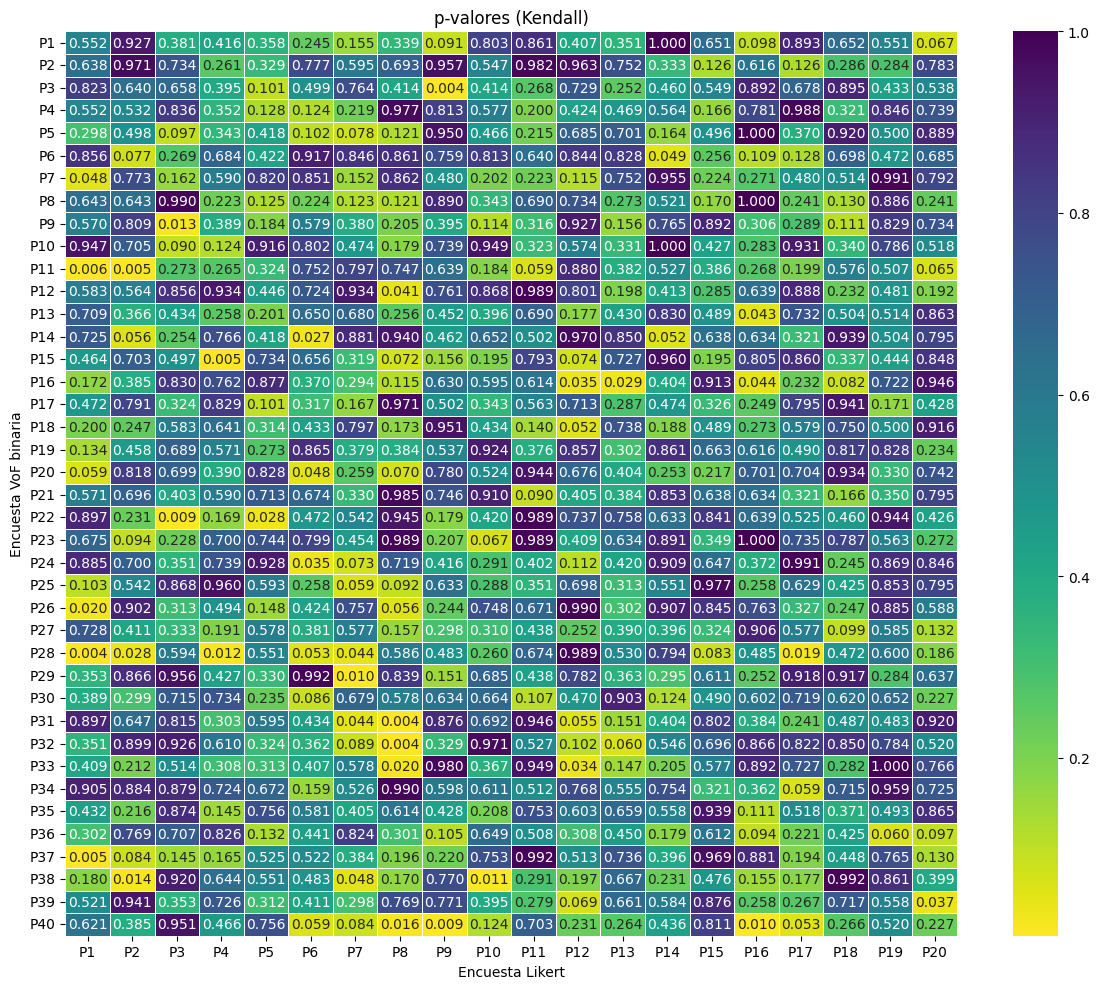

In [106]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_tau,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title("Correlaciones de Kendall (tau)")
plt.xlabel("Encuesta Likert")
plt.ylabel("Encuesta VoF binaria")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_p_kendall,
    annot=True,
    fmt=".3f",
    cmap="viridis_r",
    linewidths=0.5
)
plt.title("p-valores (Kendall)")
plt.xlabel("Encuesta Likert")
plt.ylabel("Encuesta VoF binaria")
plt.tight_layout()
plt.show()

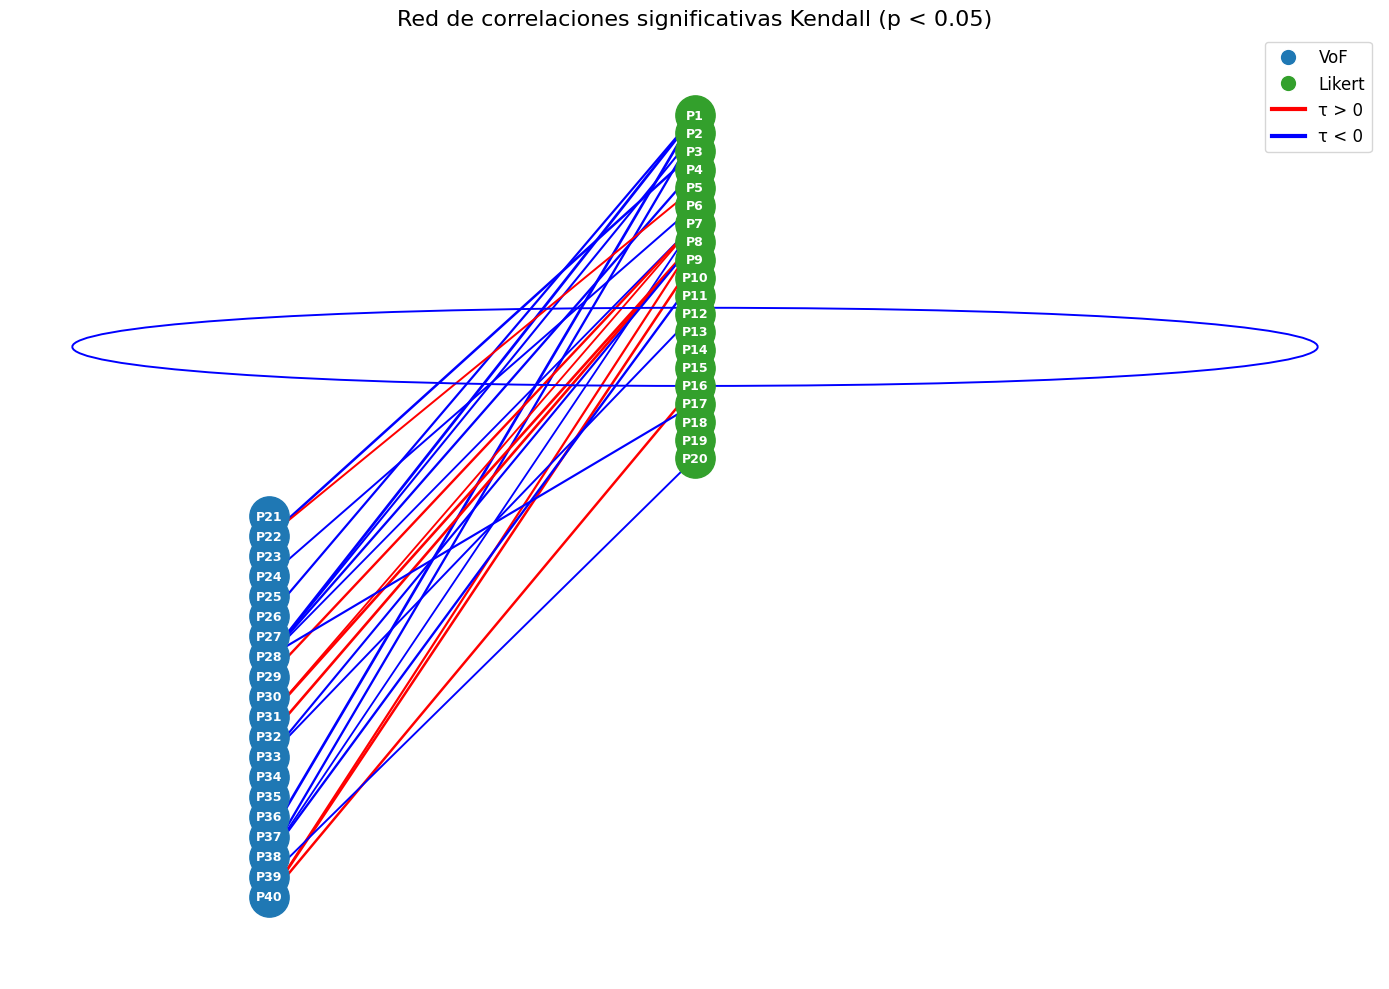

In [107]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Nivel de significancia
alpha = 0.05

# Crear grafo
G = nx.Graph()

# Nodos VoF
for vof_item in columnas_preguntas:
    G.add_node(vof_item, tipo='VoF')

# Nodos Likert
likert_items = [f"P{i}" for i in range(1, 21)]
for likert_item in likert_items:
    G.add_node(likert_item, tipo='Likert')

# Agregar aristas solo significativas (p < alpha)
for vof_item in columnas_preguntas:
    for likert_item in likert_items:
        p_val = matriz_p_kendall.loc[vof_item, likert_item]
        coef  = matriz_tau.loc[vof_item, likert_item]
        if pd.notna(coef) and pd.notna(p_val) and p_val < alpha:
            G.add_edge(vof_item, likert_item, weight=coef)

# Layout tipo bipartito horizontal
pos = {}
for i, vof_item in enumerate(columnas_preguntas):
    pos[vof_item] = (0, -i)
for i, likert_item in enumerate(likert_items):
    pos[likert_item] = (1, -i*0.9)

# Dibujar nodos
vof_nodes = [n for n,d in G.nodes(data=True) if d['tipo']=='VoF']
likert_nodes = [n for n,d in G.nodes(data=True) if d['tipo']=='Likert']

plt.figure(figsize=(14,10))
nx.draw_networkx_nodes(G, pos, nodelist=vof_nodes, node_color="#1f78b4", node_size=800, label="VoF")
nx.draw_networkx_nodes(G, pos, nodelist=likert_nodes, node_color="#33a02c", node_size=800, label="Likert")

# Dibujar aristas: color según signo, grosor según magnitud
edges = G.edges(data=True)
edge_colors = ['red' if d['weight']>0 else 'blue' for (u,v,d) in edges]
edge_widths = [abs(d['weight'])*5 for (u,v,d) in edges]
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths)

# Etiquetas
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', font_color='white')

# Leyenda
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='VoF', markerfacecolor='#1f78b4', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Likert', markerfacecolor='#33a02c', markersize=12),
    Line2D([0], [0], color='red', lw=3, label='τ > 0'),
    Line2D([0], [0], color='blue', lw=3, label='τ < 0'),
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.title(f"Red de correlaciones significativas Kendall (p < {alpha})", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

Las preguntas 14, 15 y 19 no están correlacionadas con ninguna de las preguntas de la encuesta de Likert, con una confianza del 95% de acuerdo con la prueba de Hipótesis con base en el coeficiente de Kendall.

In [108]:
from scipy.stats import mannwhitneyu

matriz_rb = pd.DataFrame(index=cols_vof, columns=cols_likert, dtype=float)
matriz_p_rb = pd.DataFrame(index=cols_vof, columns=cols_likert, dtype=float)

for vof_item in cols_vof:
    for likert_item in cols_likert:

        df_temp = pd.concat(
            [vof_bin[vof_item], multiple[likert_item]],
            axis=1
        ).dropna()

        if df_temp.iloc[:,0].nunique() == 2 and df_temp.iloc[:,1].nunique() > 1:

            grupo0 = df_temp[df_temp.iloc[:,0] == 0].iloc[:,1]
            grupo1 = df_temp[df_temp.iloc[:,0] == 1].iloc[:,1]

            if len(grupo0) > 0 and len(grupo1) > 0:

                U, p = mannwhitneyu(grupo0, grupo1, alternative="two-sided")

                n0 = len(grupo0)
                n1 = len(grupo1)

                r_rb = 1 - (2 * U) / (n0 * n1)

                matriz_rb.loc[vof_item, likert_item] = r_rb
                matriz_p_rb.loc[vof_item, likert_item] = p

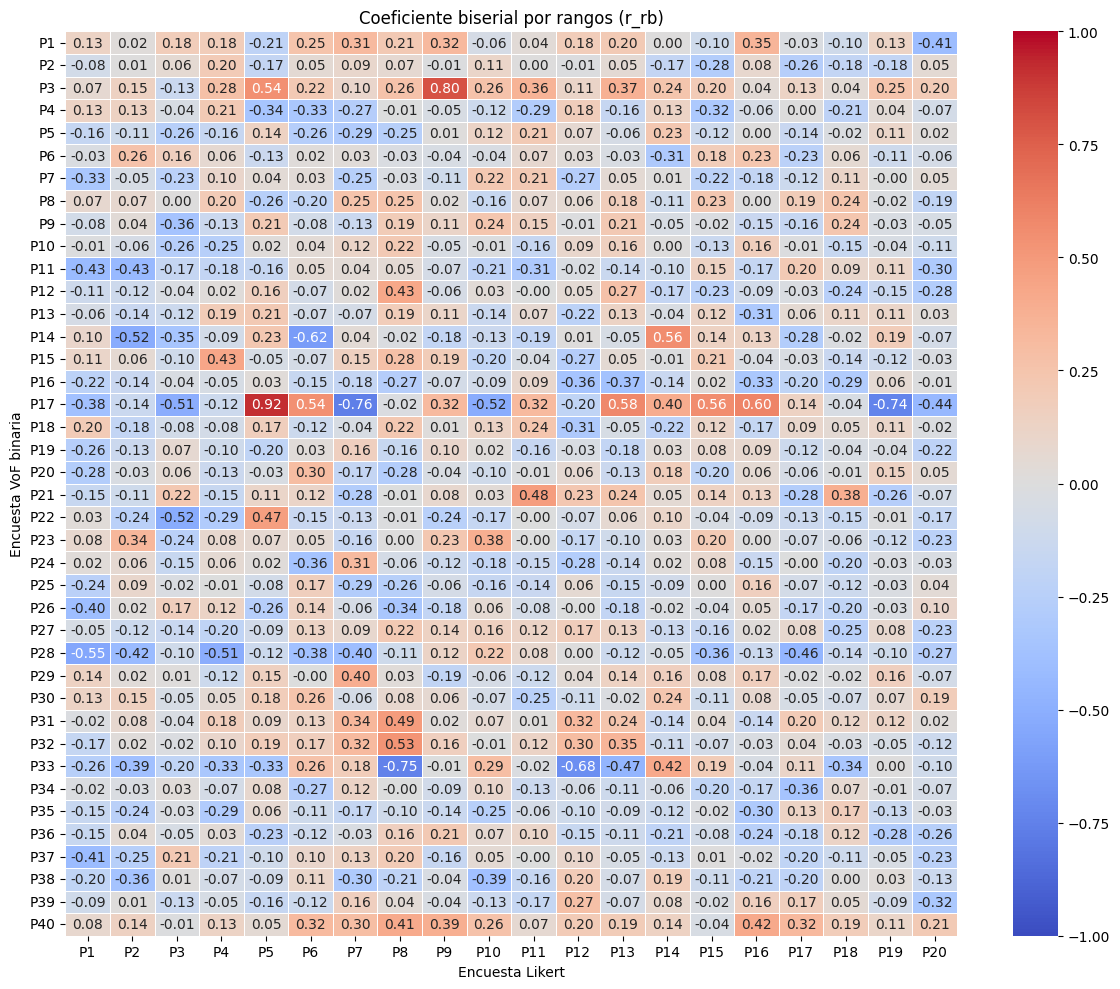

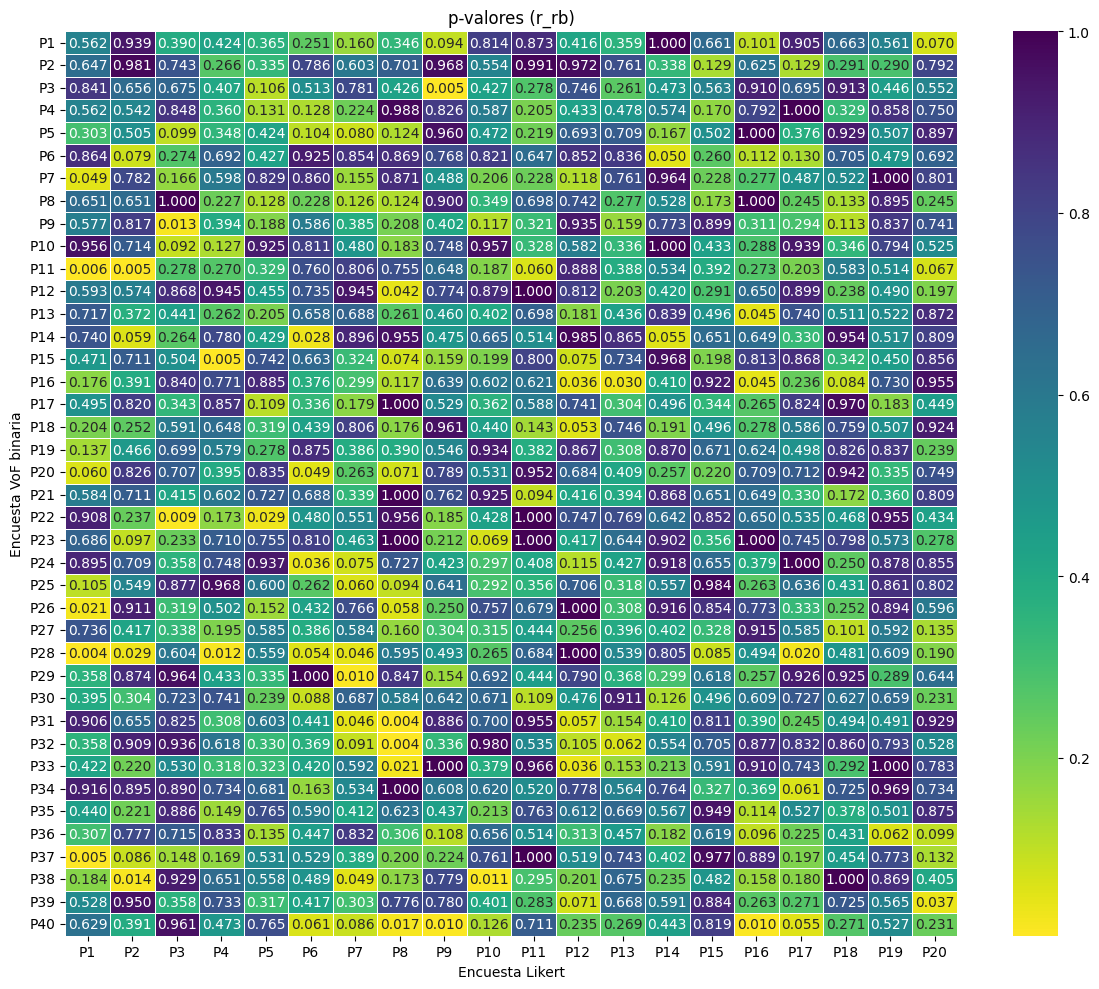

In [109]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_rb,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title("Coeficiente biserial por rangos (r_rb)")
plt.xlabel("Encuesta Likert")
plt.ylabel("Encuesta VoF binaria")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_p_rb,
    annot=True,
    fmt=".3f",
    cmap="viridis_r",
    linewidths=0.5
)
plt.title("p-valores (r_rb)")
plt.xlabel("Encuesta Likert")
plt.ylabel("Encuesta VoF binaria")
plt.tight_layout()
plt.show()

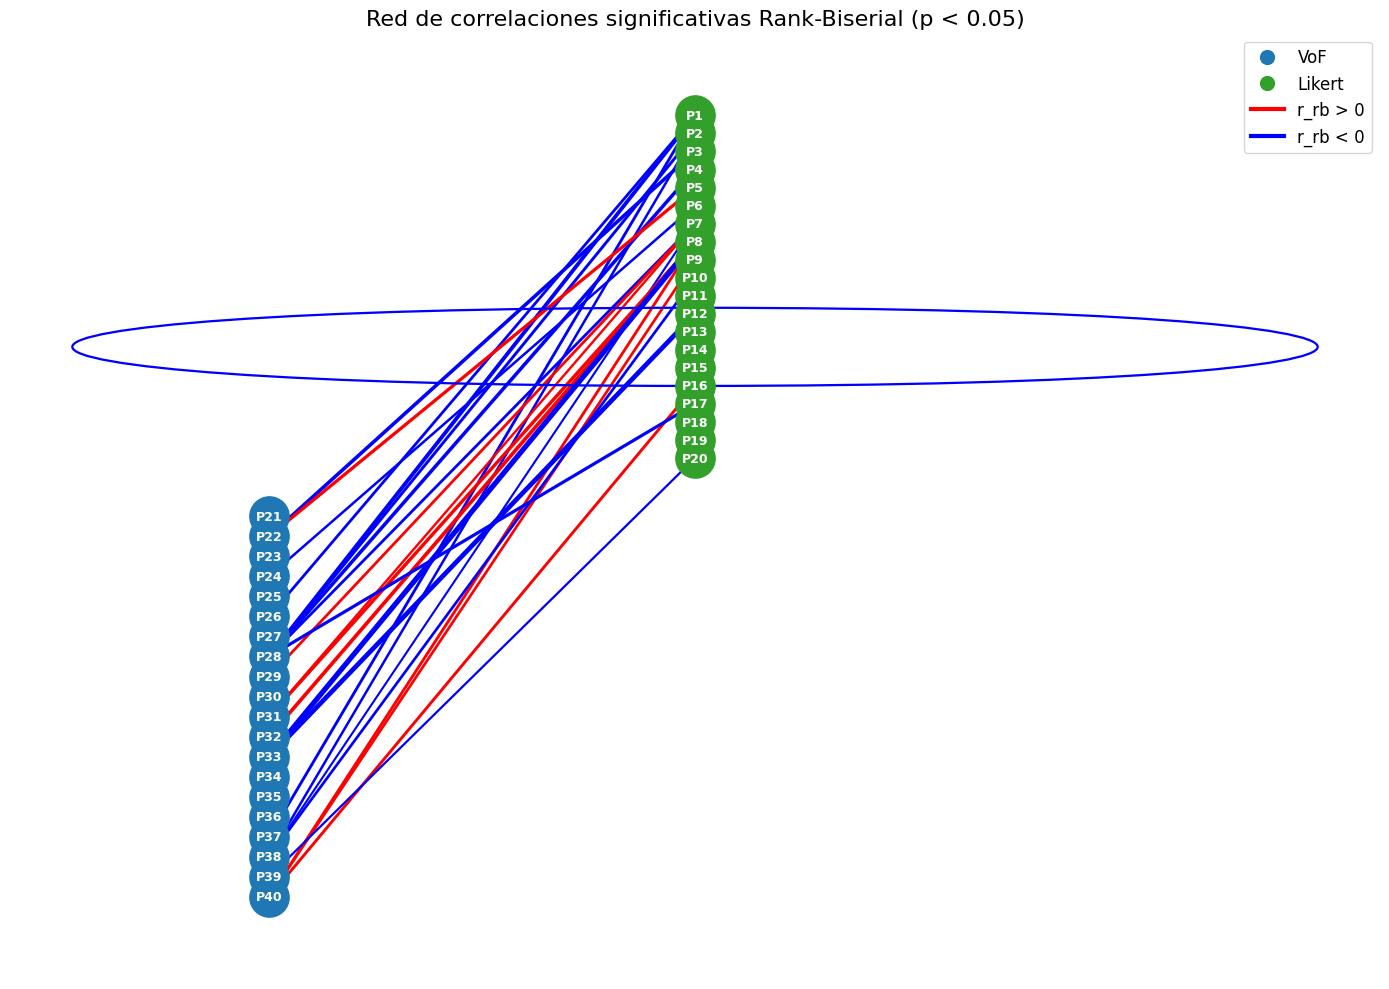

In [110]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Nivel de significancia
alpha = 0.05

# Crear grafo
G = nx.Graph()

# Nodos VoF
for vof_item in cols_vof:
    G.add_node(vof_item, tipo='VoF')

# Nodos Likert
for likert_item in cols_likert:
    G.add_node(likert_item, tipo='Likert')

# Agregar aristas solo significativas (Rank-Biserial)
for vof_item in cols_vof:
    for likert_item in cols_likert:
        p_val = matriz_p_rb.loc[vof_item, likert_item]
        coef  = matriz_rb.loc[vof_item, likert_item]
        if pd.notna(coef) and pd.notna(p_val) and p_val < alpha:
            G.add_edge(vof_item, likert_item, weight=coef)

# Layout tipo bipartito horizontal
pos = {}
for i, vof_item in enumerate(cols_vof):
    pos[vof_item] = (0, -i)
for i, likert_item in enumerate(cols_likert):
    pos[likert_item] = (1, -i*0.9)

# Dibujar nodos
vof_nodes = [n for n,d in G.nodes(data=True) if d['tipo']=='VoF']
likert_nodes = [n for n,d in G.nodes(data=True) if d['tipo']=='Likert']

plt.figure(figsize=(14,10))
nx.draw_networkx_nodes(G, pos, nodelist=vof_nodes, node_color="#1f78b4", node_size=800, label="VoF")
nx.draw_networkx_nodes(G, pos, nodelist=likert_nodes, node_color="#33a02c", node_size=800, label="Likert")

# Dibujar aristas: color según signo, grosor según magnitud
edges = G.edges(data=True)
edge_colors = ['red' if d['weight']>0 else 'blue' for (u,v,d) in edges]
edge_widths = [abs(d['weight'])*5 for (u,v,d) in edges]
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths)

# Etiquetas
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', font_color='white')

# Leyenda
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='VoF', markerfacecolor='#1f78b4', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Likert', markerfacecolor='#33a02c', markersize=12),
    Line2D([0], [0], color='red', lw=3, label='r_rb > 0'),
    Line2D([0], [0], color='blue', lw=3, label='r_rb < 0'),
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.title(f"Red de correlaciones significativas Rank-Biserial (p < {alpha})", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

Se confirma que las preguntas 14, 15 y 19 no están correlacionadas con ninguna de las preguntas bajo la escala de Likert, con una confianza del 95% bajo el coeficiente de rangos biseriales dada la prueba Mann-Whitney

In [83]:
res_spearman_top3_row = []

for vof_item in columnas_preguntas:

    # Correlaciones y p-valores
    rho_vof = matriz_rho.loc[vof_item]
    p_vof   = matriz_p.loc[vof_item]

    # Ordenar por valor absoluto y tomar top 3
    top3 = rho_vof.abs().sort_values(ascending=False).head(3).index

    # Guardar en formato fila única
    fila = {"VoF": vof_item}
    for i, likert_item in enumerate(top3, start=1):
        fila[f"Likert_top{i}"] = likert_item
        fila[f"rho{i}"] = rho_vof[likert_item]
        fila[f"p{i}"] = p_vof[likert_item]

    res_spearman_top3_row.append(fila)

# Crear DataFrame final
df_spearman_top3_row = pd.DataFrame(res_spearman_top3_row)

# Mostrar
df_spearman_top3_row

,VoF,Likert_top1,rho1,p1,Likert_top2,rho2,p2,Likert_top3,rho3,p3
0,P1,P20,-0.258587,0.066922,P9,0.238919,0.091320,P16,0.234190,0.098111
1,P2,P17,-0.216573,0.126890,P15,-0.216186,0.127588,P4,0.159043,0.264956
2,P3,P9,0.401830,0.003469,P5,0.231795,0.101696,P13,0.162167,0.255565
3,P4,P6,-0.217285,0.125617,P5,-0.215388,0.129033,P15,-0.195849,0.168405
4,P5,P7,-0.248842,0.078264,P3,-0.237046,0.097421,P6,-0.231545,0.102077
5,P6,P14,-0.278279,0.048009,P2,0.250111,0.076707,P16,0.226492,0.109994
6,P7,P1,-0.279500,0.046997,P12,-0.223017,0.115706,P7,-0.202797,0.153513
7,P8,P8,0.219111,0.122392,P7,0.218121,0.124132,P5,-0.217000,0.126125
8,P9,P3,-0.354981,0.011420,P18,0.225588,0.111458,P10,0.223370,0.115115
9,P10,P3,-0.242125,0.090248,P4,-0.217549,0.125146,P8,0.189852,0.182081


In [84]:
import pandas as pd

res_spearman_top3_row = []

for vof_item in columnas_preguntas:

    rho_vof = matriz_rho.loc[vof_item]
    p_vof   = matriz_p.loc[vof_item]

    top3 = rho_vof.abs().sort_values(ascending=False).head(3).index

    fila = {"VoF": vof_item}
    for i, likert_item in enumerate(top3, start=1):
        fila[f"Likert_top{i}"] = likert_item
        fila[f"rho{i}"] = rho_vof[likert_item]
        fila[f"p{i}"] = p_vof[likert_item]

    res_spearman_top3_row.append(fila)

df_spearman_top3_row = pd.DataFrame(res_spearman_top3_row)
df_spearman_top3_row

,VoF,Likert_top1,rho1,p1,Likert_top2,rho2,p2,Likert_top3,rho3,p3
0,P1,P20,-0.258587,0.066922,P9,0.238919,0.091320,P16,0.234190,0.098111
1,P2,P17,-0.216573,0.126890,P15,-0.216186,0.127588,P4,0.159043,0.264956
2,P3,P9,0.401830,0.003469,P5,0.231795,0.101696,P13,0.162167,0.255565
3,P4,P6,-0.217285,0.125617,P5,-0.215388,0.129033,P15,-0.195849,0.168405
4,P5,P7,-0.248842,0.078264,P3,-0.237046,0.097421,P6,-0.231545,0.102077
5,P6,P14,-0.278279,0.048009,P2,0.250111,0.076707,P16,0.226492,0.109994
6,P7,P1,-0.279500,0.046997,P12,-0.223017,0.115706,P7,-0.202797,0.153513
7,P8,P8,0.219111,0.122392,P7,0.218121,0.124132,P5,-0.217000,0.126125
8,P9,P3,-0.354981,0.011420,P18,0.225588,0.111458,P10,0.223370,0.115115
9,P10,P3,-0.242125,0.090248,P4,-0.217549,0.125146,P8,0.189852,0.182081


In [85]:
res_rb_top3_row = []

for vof_item in columnas_preguntas:

    rb_vof = matriz_rb.loc[vof_item]
    p_rb_vof = matriz_p_rb.loc[vof_item]

    # Ignorar NaN si algún ítem no tiene datos
    rb_vof_clean = rb_vof.dropna()
    if rb_vof_clean.empty:
        continue

    top3 = rb_vof_clean.abs().sort_values(ascending=False).head(3).index

    fila = {"VoF": vof_item}
    for i, likert_item in enumerate(top3, start=1):
        fila[f"Likert_top{i}"] = likert_item
        fila[f"r_rb{i}"] = rb_vof[likert_item]
        fila[f"p{i}"] = p_rb_vof[likert_item]

    res_rb_top3_row.append(fila)

df_rb_top3_row = pd.DataFrame(res_rb_top3_row)
df_rb_top3_row

,VoF,Likert_top1,r_rb1,p1,Likert_top2,r_rb2,p2,Likert_top3,r_rb3,p3
0,P1,P20,-0.409091,0.069682,P16,0.347403,0.100901,P9,0.324675,0.094422
1,P2,P15,-0.277328,0.129139,P17,-0.263158,0.128605,P4,0.198381,0.265652
2,P3,P9,0.798611,0.004853,P5,0.541667,0.105657,P13,0.368056,0.260565
3,P4,P5,-0.344156,0.131387,P6,-0.334416,0.128130,P15,-0.318182,0.170459
4,P5,P7,-0.289286,0.080340,P6,-0.264286,0.103906,P3,-0.257353,0.099462
5,P6,P14,-0.309524,0.050272,P2,0.263492,0.078765,P16,0.234921,0.111674
6,P7,P1,-0.331984,0.049494,P12,-0.273279,0.117516,P7,-0.251012,0.154903
7,P8,P5,-0.257143,0.127567,P7,0.253571,0.125650,P8,0.253571,0.123942
8,P9,P3,-0.360709,0.013369,P10,0.240741,0.116569,P18,0.237654,0.113014
9,P10,P3,-0.262868,0.092371,P4,-0.250865,0.126588,P8,0.216263,0.182953


Una vez se establece que salvo tres preguntas, las 20 preguntas de selección múltiple si están correlacionadas con algunas preguntas del formulario Likert, se procede a clasificar las preguntas de acuerdo con el contexto dado para la prueba Likert

# Análisis Factorial para clasificar las preguntas del cuestionario de selección múltiple

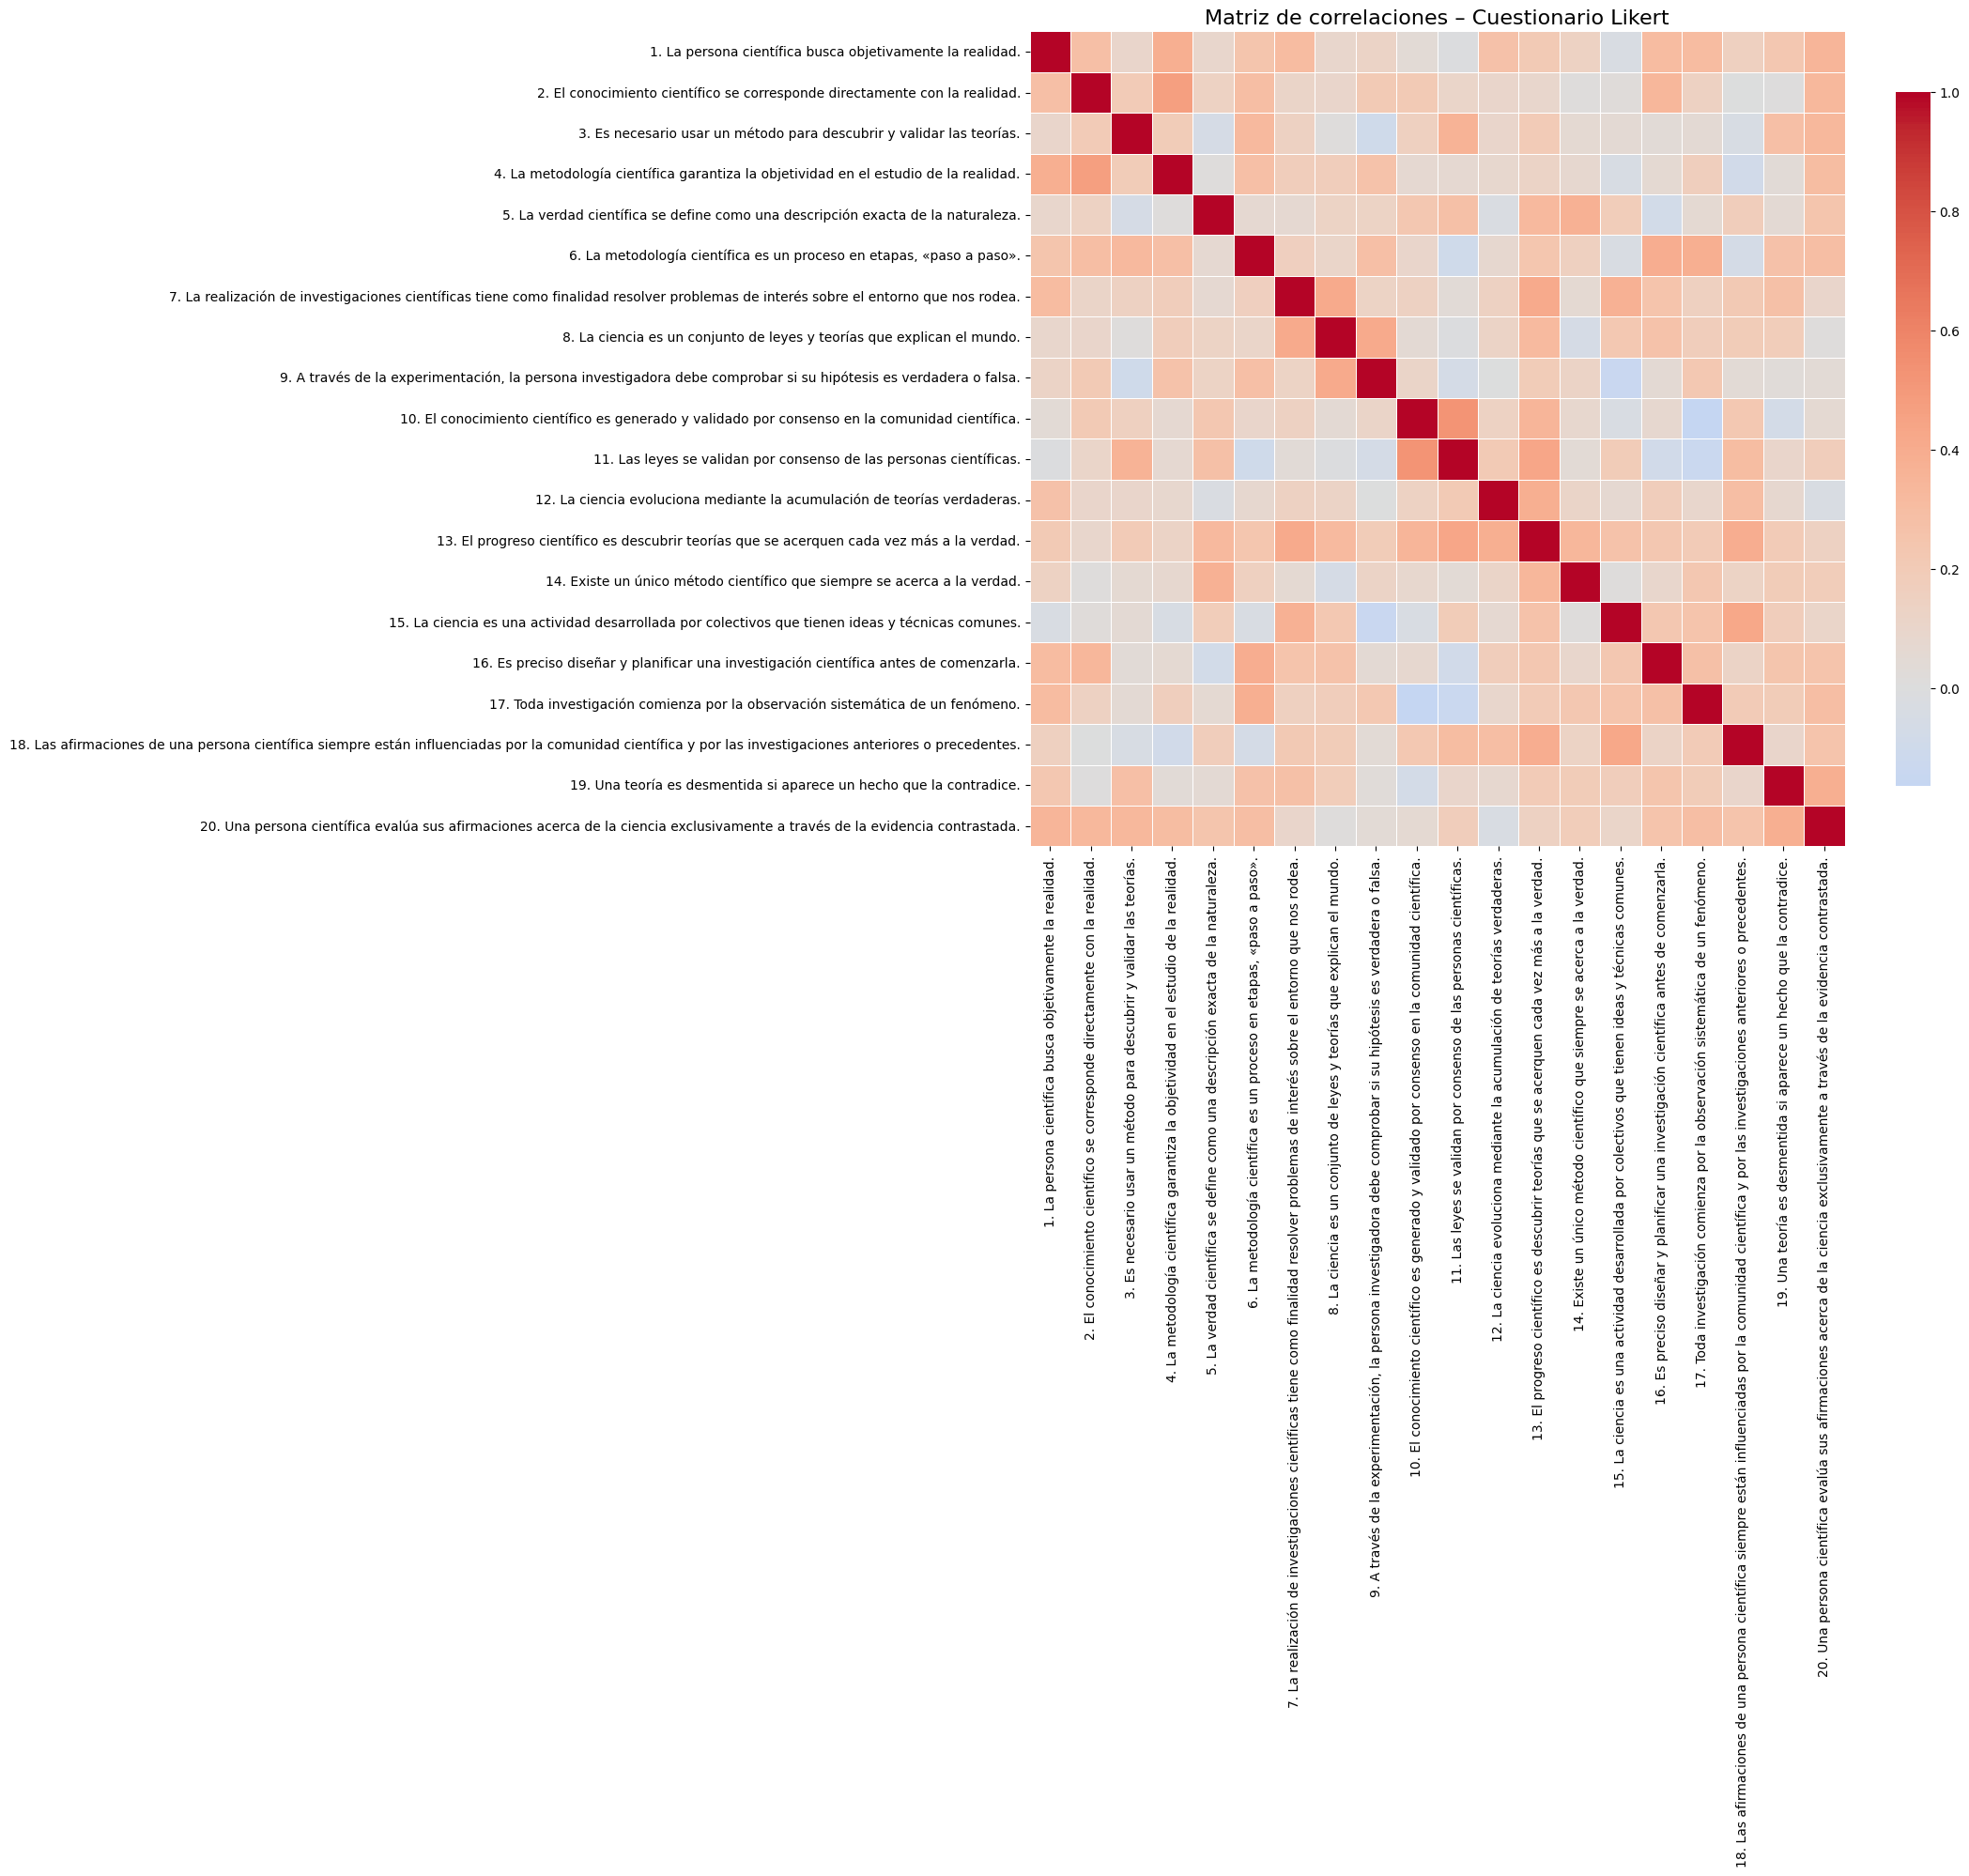

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

items = multiple.iloc[:, 5:]
corr = items.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title("Matriz de correlaciones – Cuestionario Likert", fontsize=16)
plt.show()

In [ ]:
!pip install factor_analyzer
items = multiple.iloc[:, 5:]
items = items.apply(pd.to_numeric, errors='coerce')
items = items.dropna()

In [ ]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
chi2, p = calculate_bartlett_sphericity(items)
print("Chi-cuadrado:", chi2)
print("p-valor:", p) # Se rechaza que no tengan correlación

Chi-cuadrado: 283.2078197312323
p-valor: 1.3317429489829833e-05


In [ ]:
from factor_analyzer.factor_analyzer import calculate_kmo
kmo_total, kmo_model = calculate_kmo(items)
print("KMO del modelo:", kmo_model)

KMO del modelo: 0.5656763414789053


In [ ]:
items = multiple.iloc[:, 6:]
items = items.apply(pd.to_numeric, errors='coerce').dropna()
kmo_per_item, kmo_total = calculate_kmo(items)
kmo_variables = pd.DataFrame({
    "Item": items.columns,
    "KMO": kmo_per_item
})

kmo_variables

,Item,KMO
0,2. El conocimiento científico se corresponde d...,0.591111
1,3. Es necesario usar un método para descubrir ...,0.455272
2,4. La metodología científica garantiza la obje...,0.519373
3,5. La verdad científica se define como una des...,0.408109
4,6. La metodología científica es un proceso en ...,0.594601
5,7. La realización de investigaciones científic...,0.692260
6,8. La ciencia es un conjunto de leyes y teoría...,0.538404
7,"9. A través de la experimentación, la persona ...",0.570539
8,10. El conocimiento científico es generado y v...,0.596412
9,11. Las leyes se validan por consenso de las p...,0.544685


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12

Número sugerido de factores: 3


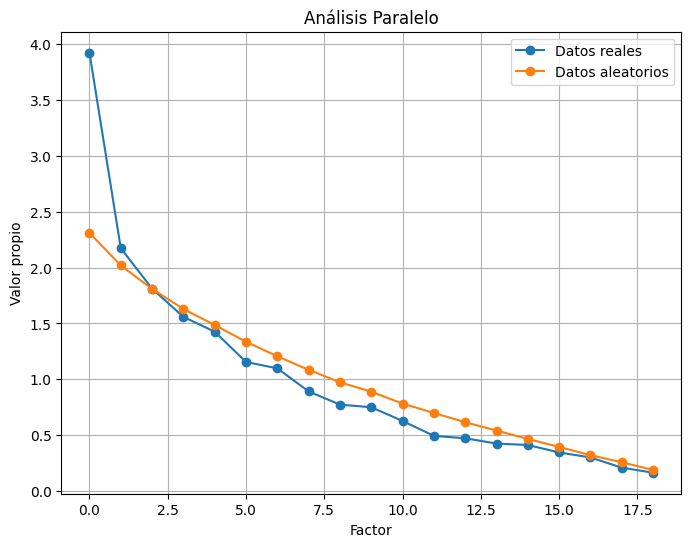

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from factor_analyzer import FactorAnalyzer

# ========= DATOS =========
items = multiple.iloc[:, 6:]
items = items.apply(pd.to_numeric, errors='coerce').dropna()

# ========= VALORES PROPIOS REALES =========
fa = FactorAnalyzer(rotation=None)
fa.fit(items)
ev, _ = fa.get_eigenvalues()

# ========= ANÁLISIS PARALELO =========
n_iter = 100
rand_ev = np.zeros((n_iter, items.shape[1]))

for i in range(n_iter):
    datos_random = np.random.normal(size=items.shape)
    fa_rand = FactorAnalyzer(rotation=None)
    fa_rand.fit(datos_random)
    rand_ev[i, :] = fa_rand.get_eigenvalues()[0]

rand_ev_mean = rand_ev.mean(axis=0)

# ========= NÚMERO DE FACTORES =========
n_factores = sum(ev > rand_ev_mean)
print("Número sugerido de factores:", n_factores)

# ========= GRÁFICA =========
plt.figure(figsize=(8,6))

plt.plot(ev, marker='o', label='Datos reales')
plt.plot(rand_ev_mean, marker='o', label='Datos aleatorios')

plt.xlabel('Factor')
plt.ylabel('Valor propio')
plt.title('Análisis Paralelo')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
items = multiple.iloc[:, 6:]   # ← ajusta si tus ítems empiezan en otra columna
items = items.apply(pd.to_numeric, errors='coerce').dropna()
from factor_analyzer import FactorAnalyzer

fa = FactorAnalyzer(
    n_factors=6,
    rotation="promax",
    method="minres"
)
fa.fit(items)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


FactorAnalyzer(n_factors=6, rotation_kwargs={})

In [ ]:
cargas = pd.DataFrame(
    fa.loadings_,
    index=items.columns,
    columns=[f"Factor{i+1}" for i in range(6)]
)
cargas

,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6
2. El conocimiento científico se corresponde directamente con la realidad.,0.142788,0.022031,0.111805,0.680412,0.032563,-0.067144
3. Es necesario usar un método para descubrir y validar las teorías.,0.379372,0.581673,-0.231473,0.140379,-0.143741,-0.169003
4. La metodología científica garantiza la objetividad en el estudio de la realidad.,0.113114,0.050897,0.224656,0.666140,-0.148443,-0.101562
5. La verdad científica se define como una descripción exacta de la naturaleza.,0.186517,-0.171253,-0.051360,0.081177,0.182195,0.572560
"6. La metodología científica es un proceso en etapas, «paso a paso».",-0.073617,0.611344,0.119521,0.154617,-0.294803,0.120467
7. La realización de investigaciones científicas tiene como finalidad resolver problemas de interés sobre el entorno que nos rodea.,0.074674,0.172621,0.459553,0.016948,0.234894,-0.146809
8. La ciencia es un conjunto de leyes y teorías que explican el mundo.,-0.022409,-0.083925,0.674920,0.127902,0.185608,-0.132443
"9. A través de la experimentación, la persona investigadora debe comprobar si su hipótesis es verdadera o falsa.",-0.054341,-0.159103,0.518595,0.237992,-0.199213,0.216671
10. El conocimiento científico es generado y validado por consenso en la comunidad científica.,0.621423,-0.154057,0.107355,0.160981,-0.053220,0.113109
11. Las leyes se validan por consenso de las personas científicas.,0.861392,-0.066326,-0.166286,0.149044,0.175148,0.050541


In [ ]:
varianza = pd.DataFrame({
    "SS Loadings": fa.get_factor_variance()[0],
    "Proportion Var": fa.get_factor_variance()[1],
    "Cumulative Var": fa.get_factor_variance()[2]
},
index=[f"Factor{i+1}" for i in range(6)])

varianza

,SS Loadings,Proportion Var,Cumulative Var
Factor1,1.772159,0.093272,0.093272
Factor2,1.731327,0.091122,0.184394
Factor3,1.559790,0.082094,0.266488
Factor4,1.342195,0.070642,0.337130
Factor5,1.267789,0.066726,0.403856
Factor6,1.231737,0.064828,0.468684


In [ ]:
cargas_filtradas = cargas.where(abs(cargas) >= 0.30, "")
cargas_filtradas

,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6
2. El conocimiento científico se corresponde directamente con la realidad.,,,,0.680412,,
3. Es necesario usar un método para descubrir y validar las teorías.,0.379372,0.581673,,,,
4. La metodología científica garantiza la objetividad en el estudio de la realidad.,,,,0.66614,,
5. La verdad científica se define como una descripción exacta de la naturaleza.,,,,,,0.57256
"6. La metodología científica es un proceso en etapas, «paso a paso».",,0.611344,,,,
7. La realización de investigaciones científicas tiene como finalidad resolver problemas de interés sobre el entorno que nos rodea.,,,0.459553,,,
8. La ciencia es un conjunto de leyes y teorías que explican el mundo.,,,0.67492,,,
"9. A través de la experimentación, la persona investigadora debe comprobar si su hipótesis es verdadera o falsa.",,,0.518595,,,
10. El conocimiento científico es generado y validado por consenso en la comunidad científica.,0.621423,,,,,
11. Las leyes se validan por consenso de las personas científicas.,0.861392,,,,,


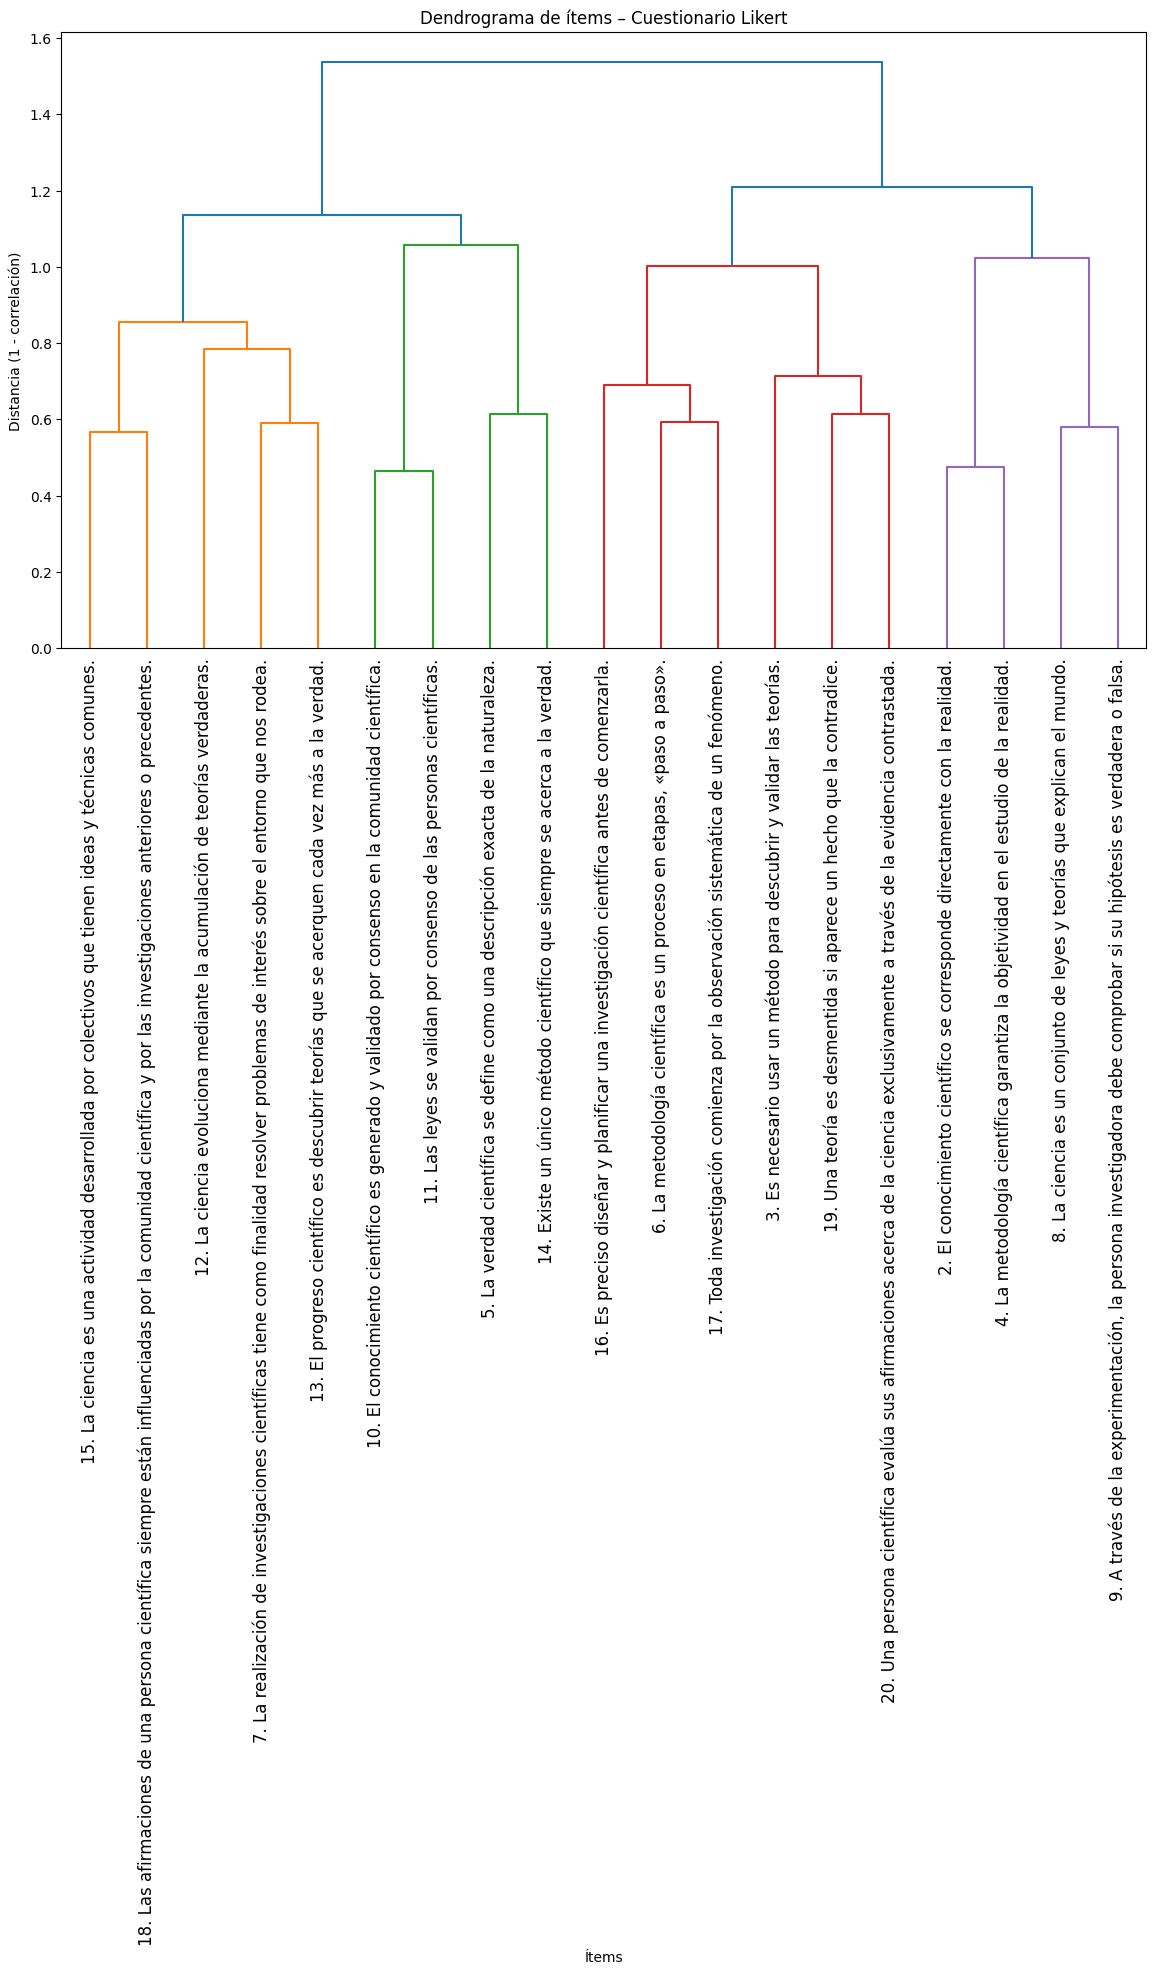

In [ ]:
items = multiple.iloc[:, 6:]   # ← ajusta si tus ítems empiezan en otra columna
items = items.apply(pd.to_numeric, errors='coerce').dropna()
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
distancia = pdist(items.T, metric='correlation')
Z = linkage(distancia, method='ward')
plt.figure(figsize=(14, 8))

dendrogram(
    Z,
    labels=items.columns,
    leaf_rotation=90
)

plt.title("Dendrograma de ítems – Cuestionario Likert")
plt.xlabel("Ítems")
plt.ylabel("Distancia (1 - correlación)")
plt.show()

# Escala Likert
En esta sección se analiza la asociación entre los resultados obtenidos en la escala Likert y las respuestas de la pregunta de selección múltiple (verdadero/falso). La variable correspondiente a la escala Likert es de naturaleza categórica ordinal, con valores que van de 1 (totalmente en desacuerdo) a 5 (totalmente de acuerdo), mientras que la variable de selección múltiple es categórica dicotómica, codificada como 0 (incorrecto) y 1 (correcto).

Dado que ambas variables son categóricas, se empleó la prueba chi-cuadrado de independencia para evaluar la existencia de asociación entre ellas. En los casos en que no se cumplieron los supuestos de frecuencia esperada mínima en las celdas de la tabla de contingencia, se utilizó la prueba exacta de Fisher como alternativa.

Considerando que las observaciones corresponden a individuos diferentes (distintos estudiantes) y que cada participante aporta una sola respuesta, se asumió la independencia de las observaciones, cumpliéndose así uno de los supuestos fundamentales para la aplicación de estas pruebas. Adicionalmente, se calculó el V de Cramer como medida del tamaño del efecto para cuantificar la fuerza de la asociación encontrada.

In [ ]:
vof_bin["puntaje_conocimiento"] = vof_bin[columnas_preguntas].sum(axis=1)
resultado = vof_bin.iloc[:, :col_inicio].copy()
resultado["puntaje_conocimiento"] = vof_bin["puntaje_conocimiento"]
resultado

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,puntaje_conocimiento
0,ARAQUE,GUTIERREZ,ANA,MARIA,13
1,AVENDAÑO,GOMEZ,MARISOL,NaN,14
2,BALLESTEROS,ORTEGA,SARAY,DALEISY,10
3,CACERES,AYALA,SARA,DEL PILAR,12
4,CALDERON,MORA,MARIA,SALOME,13
5,CANO,CAMACHO,YANZIE,ALEJANDRO,13
6,CARREÑO,MENDOZA,JOHAN,ESTEBAN,9
7,CASTILLO,RUEDA,YURLEY,FERNANDA,12
8,CAURO,CARDENAS,YOXANYS,YOELIN,13
9,CHISICA,JOHARES,JILANEY,GABRIELA,12


In [ ]:
likert = multiple.copy()
likert["puntaje_conocimiento"] = resultado["puntaje_conocimiento"]

In [ ]:
tablap1 = pd.crosstab(multiple["P1"], resultado["puntaje_conocimiento"])
print(tablap1)

puntaje_conocimiento  5   7   8   9   10  11  12  13  14  16
P1                                                          
2.0                    0   0   0   0   0   0   1   0   0   0
3.0                    0   0   0   0   1   1   1   0   0   0
4.0                    1   2   1   2   4   4   5   4   1   0
5.0                    0   1   2   2   4   3   2   5   2   2


In [ ]:
for i in range(1, 21):
    globals()[f"tablap{i}"] = pd.crosstab(
        multiple[f"P{i}"],
        resultado["puntaje_conocimiento"]
    )
print(tablap20)

puntaje_conocimiento  5   7   8   9   10  11  12  13  14  16
P20                                                         
2.0                    0   0   1   0   2   1   2   1   0   0
3.0                    0   1   0   1   2   1   4   3   2   1
4.0                    1   2   1   3   3   4   2   4   1   1
5.0                    0   0   1   0   2   2   1   1   0   0


In [ ]:
from scipy.stats import chi2_contingency
p_valores = []
for i in range(1, 21):
    tabla = globals()[f"tablap{i}"]
    # limpiar filas y columnas con solo ceros
    tabla = tabla.loc[(tabla.sum(axis=1) > 0), (tabla.sum(axis=0) > 0)]
    res = chi2_contingency(tabla)
    p_valores.append({
        "Pregunta": f"P{i}",
        "p_valor": res.pvalue
    })
df_pvalores = pd.DataFrame(p_valores)
df_pvalores

,Pregunta,p_valor
0,P1,0.984327
1,P2,0.694457
2,P3,0.787307
3,P4,0.466831
4,P5,0.693741
5,P6,0.541726
6,P7,0.055283
7,P8,0.000200
8,P9,0.496834
9,P10,0.417463


In [ ]:
for c in likert.columns:
    print(c)

Unnamed: 0
Unnamed: 1
Unnamed: 2
Unnamed: 3
ASIGNATURA
1. La persona científica busca objetivamente la realidad.
2. El conocimiento científico se corresponde directamente con la realidad.
3. Es necesario usar un método para descubrir y validar las teorías.
4. La metodología científica garantiza la objetividad en el estudio de la realidad.
5. La verdad científica se define como una descripción exacta de la naturaleza.
6. La metodología científica es un proceso en etapas, «paso a paso».
7. La realización de investigaciones científicas tiene como finalidad resolver problemas de interés sobre el entorno que nos rodea.
8. La ciencia es un conjunto de leyes y teorías que explican el mundo.
9. A través de la experimentación, la persona investigadora debe comprobar si su hipótesis es verdadera o falsa.
10. El conocimiento científico es generado y validado por consenso en la comunidad científica.
11. Las leyes se validan por consenso de las personas científicas.
12. La ciencia evoluciona median

In [ ]:
from scipy.stats import mannwhitneyu
import pandas as pd
import numpy as np

resultados1 = []

for i in range(1, 21):

    var = f"P{i}"

    # asegurar que la columna exista
    if var not in likert.columns:
        continue

    # seleccionar variables y eliminar NA
    df_temp = likert[["puntaje_conocimiento", var]].dropna()

    # convertir a numérico por si vienen como texto
    df_temp["puntaje_conocimiento"] = pd.to_numeric(df_temp["puntaje_conocimiento"], errors="coerce")
    df_temp[var] = pd.to_numeric(df_temp[var], errors="coerce")

    df_temp = df_temp.dropna()

    grupo0 = df_temp[df_temp[var] == 0]["puntaje_conocimiento"]
    grupo1 = df_temp[df_temp[var] == 1]["puntaje_conocimiento"]

    if len(grupo0) > 0 and len(grupo1) > 0:

        U, p = mannwhitneyu(
            grupo0,
            grupo1,
            alternative="two-sided",
            method="asymptotic"   # 👈 evita errores con empates
        )

        n0 = len(grupo0)
        n1 = len(grupo1)

        r_rb = 1 - (2 * U) / (n0 * n1)

    else:
        U, p, r_rb = np.nan, np.nan, np.nan

    resultados1.append({
        "Pregunta": var,
        "n_0": len(grupo0),
        "n_1": len(grupo1),
        "U": U,
        "p_valor": p,
        "r_rank_biserial": r_rb
    })

df_rb = pd.DataFrame(resultados1)

df_rb

""


In [ ]:
from scipy.stats import fisher_exact
import pandas as pd
resultados_fisher = []
for i in range(1, 21):
    tabla = globals()[f"tabla{i}"]
    # quitar filas o columnas con puros ceros
    tabla = tabla.loc[(tabla.sum(axis=1) > 0), (tabla.sum(axis=0) > 0)]
    try:
        _, p = fisher_exact(tabla, method="monte_carlo")
    except:
        p = None   # por si tu versión de scipy no lo soporta
    resultados_fisher.append({
        "Pregunta": f"P{i}",
        "p_valor": p
    })
df_fisher = pd.DataFrame(resultados_fisher)
df_fisher

,Pregunta,p_valor
0,P1,None
1,P2,None
2,P3,None
3,P4,None
4,P5,None
5,P6,None
6,P7,None
7,P8,None
8,P9,None
9,P10,None


In [ ]:
vof_bin

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,1. La principal razón por las que un país debería invertir en ciencia es:,2. Un país ¿es más rico porque es puntero en ciencia o es puntero porque es más rico?,3. ¿Con qué intensidad se relaciona la ciencia (C) y la tecnología (T) ?,4. ¿Avanzaría más rápido y mejor la ciencia si estuviese controlada por las empresas privadas?,5. ¿Son responsables los científicos del daño que pueda resultar de sus descubrimientos?,...,32. ¿Deberían intentar los científicos no cometer errores?,33. La ciencia ¿se parece en algo a la novela?,34. Es más adecuado pensar que la tarea principal de la ciencia es:,35. Los modelos científicos ¿reproducen la realidad?,36. ¿Es necesario que un científico tenga que convencer a sus colegas de la validez de su descubrimiento?,"37. Sobre la constitución de la materia, una nueva teoría termina siendo aceptada por los expertos en detrimento de la antigua. Lo más probable es que a partir de ahora la realidad material se:","38. De pronto, un experimento aporta datos que contradicen la actual teoría de la luz ¿qué es lo más probable que revisen en un primer momento los científicos?",39. Los datos acumulados en un año muestran que una teoría está equivocada ¿qué harán los expertos?,40. Recientemente se ha anunciado en los medios de comunicación el éxito de la primera clonación humana ¿es usual en ámbitos científicos la rápida publicación?,puntaje_conocimiento
0,ARAQUE,GUTIERREZ,ANA,MARIA,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,2,13
1,AVENDAÑO,GOMEZ,MARISOL,NaN,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,2,14
2,BALLESTEROS,ORTEGA,SARAY,DALEISY,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,3,10
3,CACERES,AYALA,SARA,DEL PILAR,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,2,12
4,CALDERON,MORA,MARIA,SALOME,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,2,13
5,CANO,CAMACHO,YANZIE,ALEJANDRO,0,0,1,0,0,0,...,1,0,1,1,0,0,1,0,1,13
6,CARREÑO,MENDOZA,JOHAN,ESTEBAN,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,2,9
7,CASTILLO,RUEDA,YURLEY,FERNANDA,0,0,1,0,0,0,...,0,0,0,0,1,0,1,0,2,12
8,CAURO,CARDENAS,YOXANYS,YOELIN,0,0,0,0,0,0,...,0,1,1,0,1,0,0,0,2,13
9,CHISICA,JOHARES,JILANEY,GABRIELA,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,2,12


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

cols_vof = columnas_preguntas              # ítems V/F binarios
cols_likert = [f"P{i}" for i in range(1, 21)]

matriz_rb = pd.DataFrame(index=cols_vof, columns=cols_likert, dtype=float)
matriz_p  = pd.DataFrame(index=cols_vof, columns=cols_likert, dtype=float)

for vof_item in cols_vof:

    # verificar que tenga 0 y 1
    if vof_bin[vof_item].nunique() < 2:
        continue

    for likert_item in cols_likert:

        df_temp = pd.concat(
            [vof_bin[vof_item], multiple[likert_item]],
            axis=1
        ).dropna()

        df_temp.columns = ["vf", "lk"]

        grupo0 = df_temp[df_temp["vf"] == 0]["lk"]
        grupo1 = df_temp[df_temp["vf"] == 1]["lk"]

        if len(grupo0) > 0 and len(grupo1) > 0:

            U, p = mannwhitneyu(grupo0, grupo1, alternative="two-sided")

            n0 = len(grupo0)
            n1 = len(grupo1)

            r_rb = 1 - (2 * U) / (n0 * n1)

            matriz_rb.loc[vof_item, likert_item] = r_rb
            matriz_p.loc[vof_item, likert_item]  = p

In [ ]:
matriz_rb

,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20
Unnamed: 4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1. La principal razón por las que un país debería invertir en ciencia es:,-0.380000,-0.140000,-0.510204,-0.720000,0.560000,-0.320000,-0.160000,-0.020000,-0.660000,-0.520000,-0.460000,-0.200000,-0.820000,0.400000,-0.580000,-0.360000,0.140000,-0.040000,-0.020000,0.300000
2. Un país ¿es más rico porque es puntero en ciencia o es puntero porque es más rico?,-0.078947,0.006073,0.056133,0.198381,-0.174089,0.048583,0.093117,0.068826,-0.008097,0.105263,0.004049,-0.008097,0.054656,-0.172065,-0.277328,0.082996,-0.263158,-0.182186,-0.184211,0.048583
3. ¿Con qué intensidad se relaciona la ciencia (C) y la tecnología (T) ?,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4. ¿Avanzaría más rápido y mejor la ciencia si estuviese controlada por las empresas privadas?,-0.387755,-0.500000,-0.520833,-0.428571,0.408163,0.551020,-0.061224,-0.377551,0.326531,-0.122449,-0.071429,-0.612245,0.163265,0.408163,0.571429,0.122449,0.500000,0.367347,0.010204,-0.071429
5. ¿Son responsables los científicos del daño que pueda resultar de sus descubrimientos?,0.571429,-0.142857,-0.031250,0.653061,0.408163,0.112245,0.653061,0.367347,-0.173469,0.591837,0.877551,-0.061224,0.591837,-0.204082,0.275510,-0.367347,0.091837,0.367347,0.377551,0.224490
6. ¿Cuál es la razón principal por la que el científico suele actuar con honradez?,-0.663265,-0.500000,0.448980,0.265306,-0.122449,-0.153061,-0.163265,0.367347,-0.173469,-0.530612,-0.071429,-0.561224,-0.265306,0.306122,0.275510,-0.367347,0.142857,-0.408163,-0.020408,-0.448980
7. ¿Influye en los descubrimientos del científico sus creencias religiosas?,-0.331984,-0.048583,-0.230769,0.095142,0.040486,0.032389,-0.251012,-0.030364,-0.107287,0.222672,0.214575,-0.273279,0.054656,0.010121,-0.220648,-0.182186,-0.121457,0.111336,-0.002024,0.046559
"8. El refrán ""la paciencia es la madre de la ciencia"" hace referencia a que los expertos cuando hacen ciencia:",-0.149351,-0.272727,-0.112957,-0.207792,0.000000,0.250000,-0.474026,0.110390,0.045455,-0.233766,-0.340909,-0.204545,-0.159091,0.487013,-0.678571,-0.347403,0.272727,-0.431818,-0.129870,-0.211039
9. La formación y el carácter personal del científico ¿puede influir en sus descubrimientos?,-0.038462,0.163968,0.203742,0.044534,-0.072874,0.135628,0.010121,-0.467611,-0.107287,0.062753,0.135628,0.062753,-0.143725,0.192308,-0.168016,0.012146,0.072874,-0.115385,-0.008097,0.050607


In [ ]:
matriz_p

,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20
Unnamed: 4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1. La principal razón por las que un país debería invertir en ciencia es:,0.495348,0.820497,0.343234,0.206780,0.335627,0.578663,0.799149,1.000000,0.179672,0.362175,0.426806,0.741058,0.141920,0.496146,0.326081,0.513760,0.824185,0.970254,1.000000,0.614091
2. Un país ¿es más rico porque es puntero en ciencia o es puntero porque es más rico?,0.646997,0.980803,0.743124,0.265652,0.334874,0.786464,0.602785,0.701454,0.968078,0.554255,0.990831,0.972045,0.761347,0.338450,0.129139,0.624975,0.128605,0.291046,0.289648,0.792128
3. ¿Con qué intensidad se relaciona la ciencia (C) y la tecnología (T) ?,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4. ¿Avanzaría más rápido y mejor la ciencia si estuviese controlada por las empresas privadas?,0.316781,0.194767,0.166822,0.290807,0.320511,0.161044,0.896708,0.347755,0.353173,0.774582,0.876975,0.121777,0.694027,0.318366,0.168247,0.762801,0.204257,0.351219,1.000000,0.877326
5. ¿Son responsables los científicos del daño que pueda resultar de sus descubrimientos?,0.136720,0.725465,0.955001,0.104552,0.320511,0.791435,0.101893,0.361310,0.631795,0.137809,0.028302,0.895671,0.134939,0.626883,0.514819,0.336911,0.832430,0.351219,0.341623,0.589018
6. ¿Cuál es la razón principal por la que el científico suele actuar con honradez?,0.083340,0.194767,0.406923,0.519499,0.779330,0.711214,0.696934,0.361310,0.631795,0.184247,0.876975,0.156709,0.512043,0.458105,0.514819,0.336911,0.730976,0.298912,0.978926,0.268620
7. ¿Influye en los descubrimientos del científico sus creencias religiosas?,0.049494,0.781994,0.165593,0.597585,0.829331,0.859762,0.154903,0.870804,0.487891,0.206242,0.227575,0.117516,0.761347,0.963643,0.228173,0.276769,0.487041,0.521772,1.000000,0.800971
"8. El refrán ""la paciencia es la madre de la ciencia"" hace referencia a que los expertos cuando hacen ciencia:",0.492215,0.205984,0.599018,0.359879,1.000000,0.256929,0.033700,0.627319,0.826164,0.297092,0.130132,0.359033,0.477644,0.031526,0.003290,0.100901,0.215618,0.047345,0.561162,0.353016
9. La formación y el carácter personal del científico ¿puede influir en sus descubrimientos?,0.828272,0.335793,0.221464,0.809565,0.691307,0.436936,0.963105,0.007543,0.487891,0.727930,0.448180,0.726011,0.413537,0.284085,0.360209,0.951278,0.680118,0.506471,0.971843,0.783311


/tmp/ipython-input-2728146086.py:23: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


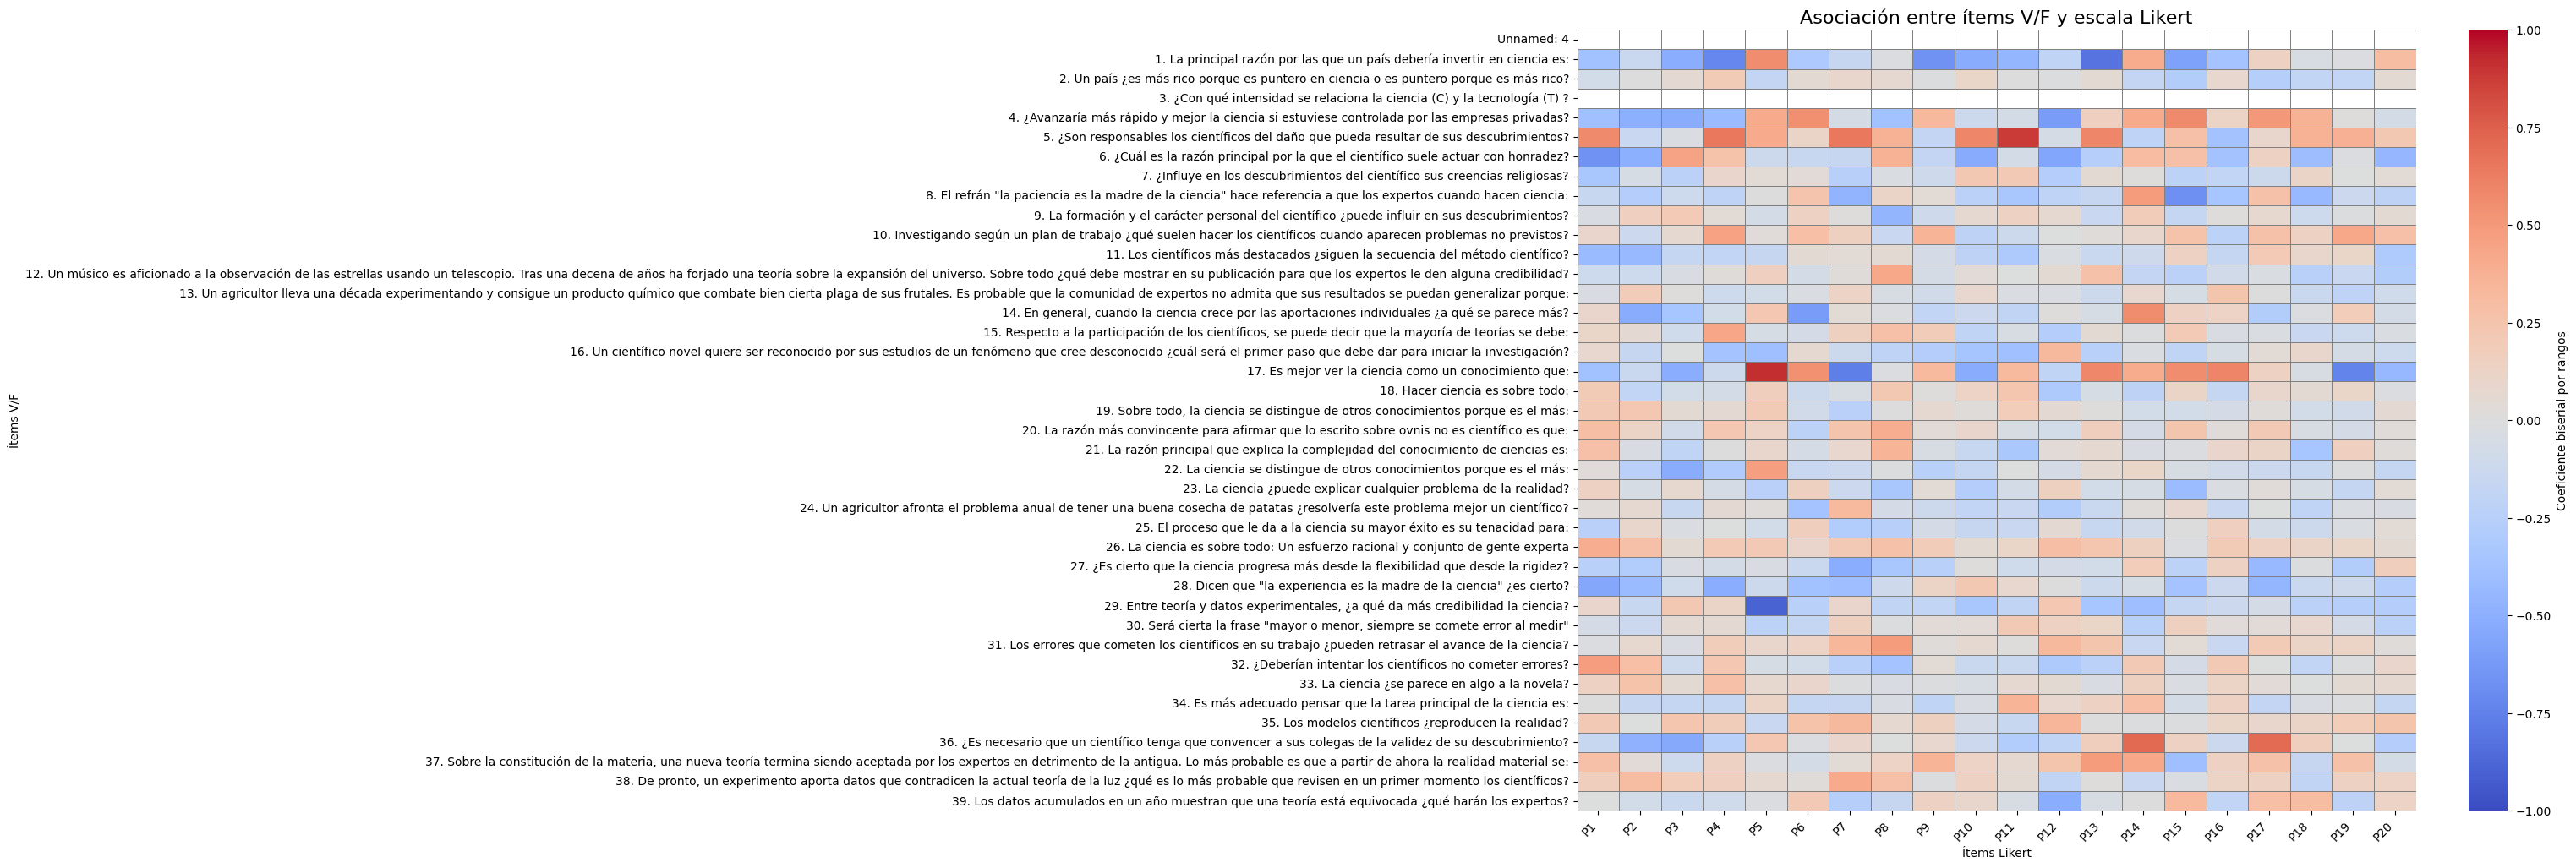

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 12))

sns.heatmap(
    matriz_rb.astype(float),
    cmap="coolwarm",      # azul = negativo, rojo = positivo
    center=0,             # el 0 queda en blanco
    vmin=-1, vmax=1,      # escala completa del coeficiente
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Coeficiente biserial por rangos"}
)

plt.title("Asociación entre ítems V/F y escala Likert", fontsize=16)
plt.xlabel("Ítems Likert")
plt.ylabel("Ítems V/F")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()